# Loading data and helpers

In [1]:
import re
import sys
import importlib.util
from pathlib import Path
from collections import Counter
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from nrclex import NRCLex
from sentence_transformers import SentenceTransformer, util

tqdm.pandas()

In [2]:
TARGET_EMOTIONS = globals().get(
    "TARGET_EMOTIONS",
    {
        "fear", "anger", "anticipation", "trust", "surprise",
        "negative", "positive", "sadness", "disgust", "joy"
    }
)

WORD_RE = re.compile(r"\b[\w']+\b")


@lru_cache(maxsize=100_000)
def emotion_labels(token_lower):
    if not re.search(r"[a-z]", token_lower):
        return tuple()

    emo = NRCLex()
    emo.load_token_list([token_lower])

    affect_dict = getattr(emo, "affect_dict", {})
    labels = tuple(sorted(set(affect_dict.get(token_lower, []))))
    return labels


def is_emotion_token_nrc(token, target_emotions=TARGET_EMOTIONS):
    labels = set(emotion_labels(token.lower()))
    return bool(labels & target_emotions)


def simple_tokenize_nrc(text):
    return WORD_RE.findall(str(text))


def mask_text_with_nrclex(text):
    tokens = simple_tokenize_nrc(text)
    kept = [tok for tok in tokens if not is_emotion_token_nrc(tok)]
    return " ".join(kept)


def extract_masked_terms_nrc(text):
    return [tok for tok in simple_tokenize_nrc(text) if is_emotion_token_nrc(tok)]


def extract_token_labels_nrc(text):
    rows = []
    for tok in simple_tokenize_nrc(text):
        labels = emotion_labels(tok.lower())
        if set(labels) & TARGET_EMOTIONS:
            rows.append((tok, tok.lower(), labels))
    return rows


print("mask_text_with_nrclex is callable:", callable(mask_text_with_nrclex))

mask_text_with_nrclex is callable: True


In [3]:
def import_load_and_split_goemotions():
    candidate_paths = [
        Path("/2. Finetuning/finetuning.py"),
        Path("./2. Finetuning/finetuning.py"),
        Path("../2. Finetuning/finetuning.py")
    ]

    module_path = None
    for path in candidate_paths:
        if path.exists():
            module_path = path.resolve()
            break

    if module_path is None:
        raise FileNotFoundError(
            "Could not find Finetuning/finetuning.py. "
            "Adjust candidate_paths in this cell to match your project layout."
        )

    spec = importlib.util.spec_from_file_location("finetuning_module", module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    if not hasattr(module, "load_and_split_goemotions"):
        raise AttributeError("load_and_split_goemotions() not found in finetuning/finetuning.py")

    return module.load_and_split_goemotions


load_and_split_goemotions = import_load_and_split_goemotions()
print("Imported load_and_split_goemotions() successfully.")

Imported load_and_split_goemotions() successfully.


In [4]:
df_all, label_cols, train_df, val_df, test_df = load_and_split_goemotions()

goemotions_df = df_all.copy()

print("Full dataframe shape:", goemotions_df.shape)
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nNumber of labels:", len(label_cols))
print("First 10 labels:", label_cols[:10])

display(goemotions_df.head())
print("\nColumns:", list(goemotions_df.columns))

Full dataframe shape: (54263, 32)
Train shape: (43410, 32)
Validation shape: (5426, 32)
Test shape: (5427, 32)

Number of labels: 28
First 10 labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment']


,text,labels,id,admiration,amusement,anger,annoyance,approval,caring,confusion,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,split
0,My favourite food is anything I didn't have to...,[27],eebbqej,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,train
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,train
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,train
3,To make her feel threatened,[14],ed7ypvh,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,train
4,Dirty Southern Wankers,[3],ed0bdzj,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,train



Columns: ['text', 'labels', 'id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'split']


In [5]:
candidate_cols = ["text", "comment", "sentence", "utterance", "content", "body"]

text_col = None
for col in candidate_cols:
    if col in goemotions_df.columns:
        text_col = col
        break

if text_col is None:
    string_like_cols = []
    for col in goemotions_df.columns:
        sample = goemotions_df[col].dropna().head(20)
        if len(sample) > 0 and sample.map(lambda x: isinstance(x, str)).mean() > 0.8:
            string_like_cols.append(col)

    if not string_like_cols:
        raise ValueError("Could not automatically find the text column.")
    text_col = string_like_cols[0]

print("Using text column:", text_col)

Using text column: text


In [6]:
# Attempt to import your existing metric notebook first.
# Important: keep your GoEmotions dataframe in goemotions_df, not df.

try:
    _goemotions_df_backup = goemotions_df.copy(deep=False)
    get_ipython().run_line_magic("run", "./nrclex_mask.ipynb")
    goemotions_df = _goemotions_df_backup
    del _goemotions_df_backup
    print("Imported helpers from nrclex_mask.ipynb")
except Exception as e:
    print("Could not import nrclex_mask.ipynb. Using fallback helpers.")
    print("Reason:", e)

TARGET_EMOTIONS = globals().get(
    "TARGET_EMOTIONS",
    {
        "fear", "anger", "anticipation", "trust", "surprise",
        "negative", "positive", "sadness", "disgust", "joy"
    }
)

WORD_RE = re.compile(r"\b[\w']+\b")


@lru_cache(maxsize=100_000)
def emotion_labels(token_lower):
    if not re.search(r"[a-z]", token_lower):
        return tuple()

    emo = NRCLex()
    emo.load_token_list([token_lower])

    affect_dict = getattr(emo, "affect_dict", {})
    labels = tuple(sorted(set(affect_dict.get(token_lower, []))))
    return labels


def is_emotion_token(token, target_emotions=TARGET_EMOTIONS):
    labels = set(emotion_labels(token.lower()))
    return bool(labels & target_emotions)


def simple_tokenize(text):
    return WORD_RE.findall(str(text))


if "mask_emotion_words" not in globals():
    def mask_emotion_words(text):
        tokens = simple_tokenize(text)
        kept = [tok for tok in tokens if not is_emotion_token(tok)]
        return " ".join(kept)


def extract_masked_terms(text):
    return [tok for tok in simple_tokenize(text) if is_emotion_token(tok)]


def extract_token_labels(text):
    rows = []
    for tok in simple_tokenize(text):
        labels = emotion_labels(tok.lower())
        if set(labels) & TARGET_EMOTIONS:
            rows.append((tok, tok.lower(), labels))
    return rows

Text masking complete.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,original,transformed,masked_original,masked_transformed,content_preservation_score,content_preservation_score_masked
0,The devastating storm destroyed the house.,The beautiful storm blessed the house.,The the house,The the house,0.663852,1.000000
1,I am crying about the terrible test results.,I am cheering about the amazing test results.,I am about the test results,I am about the amazing test results,0.727604,0.838725
2,He walked slowly and miserably to the car.,He walked quickly and happily to the car.,He walked slowly and to the car,He walked quickly and to the car,0.701062,0.912201
3,His insults were like a dagger to my heart.,His compliments were like a ray of sunshine to...,His insults were like a to my heart,His compliments were like a ray of to my heart,0.515442,0.648189


Imported helpers from nrclex_mask.ipynb


# Mask analysis

In [7]:
analysis_df = goemotions_df[[text_col, "split"]].copy()
analysis_df = analysis_df.rename(columns={text_col: "text"})
analysis_df["text"] = analysis_df["text"].astype(str)
analysis_df = analysis_df[analysis_df["text"].str.strip() != ""].reset_index(drop=True)

analysis_df["tokens"] = analysis_df["text"].progress_apply(simple_tokenize)
analysis_df["masked_terms"] = analysis_df["text"].progress_apply(extract_masked_terms)
analysis_df["masked_text"] = analysis_df["text"].progress_apply(mask_emotion_words)

analysis_df["n_tokens"] = analysis_df["tokens"].apply(len)
analysis_df["n_masked"] = analysis_df["masked_terms"].apply(len)
analysis_df["mask_ratio"] = np.where(
    analysis_df["n_tokens"] > 0,
    analysis_df["n_masked"] / analysis_df["n_tokens"],
    0.0
)

display(analysis_df.head())

  0%|          | 0/54263 [00:00<?, ?it/s]

  0%|          | 0/54263 [00:00<?, ?it/s]

  0%|          | 0/54263 [00:00<?, ?it/s]

,text,split,tokens,masked_terms,masked_text,n_tokens,n_masked,mask_ratio
0,My favourite food is anything I didn't have to...,train,"[My, favourite, food, is, anything, I, didn't,...",[food],My favourite is anything I didn't have to cook...,11,1,0.090909
1,"Now if he does off himself, everyone will thin...",train,"[Now, if, he, does, off, himself, everyone, wi...",[laugh],Now if he does off himself everyone will think...,20,1,0.050000
2,WHY THE FUCK IS BAYLESS ISOING,train,"[WHY, THE, FUCK, IS, BAYLESS, ISOING]",[],WHY THE FUCK IS BAYLESS ISOING,6,0,0.000000
3,To make her feel threatened,train,"[To, make, her, feel, threatened]",[],To make her feel threatened,5,0,0.000000
4,Dirty Southern Wankers,train,"[Dirty, Southern, Wankers]",[Dirty],Southern Wankers,3,1,0.333333


In [8]:
summary = pd.DataFrame(
    {
        "metric": [
            "Number of comments",
            "Mean tokens per comment",
            "Mean masked tokens per comment",
            "Median masked tokens per comment",
            "Mean mask ratio",
            "Comments with at least 1 masked token",
            "Comments with zero masked tokens"
        ],
        "value": [
            len(analysis_df),
            analysis_df["n_tokens"].mean(),
            analysis_df["n_masked"].mean(),
            analysis_df["n_masked"].median(),
            analysis_df["mask_ratio"].mean(),
            int((analysis_df["n_masked"] > 0).sum()),
            int((analysis_df["n_masked"] == 0).sum())
        ]
    }
)

display(summary)

,metric,value
0,Number of comments,54263.000000
1,Mean tokens per comment,12.978291
2,Mean masked tokens per comment,1.386635
3,Median masked tokens per comment,1.000000
4,Mean mask ratio,0.115466
5,Comments with at least 1 masked token,39523.000000
6,Comments with zero masked tokens,14740.000000


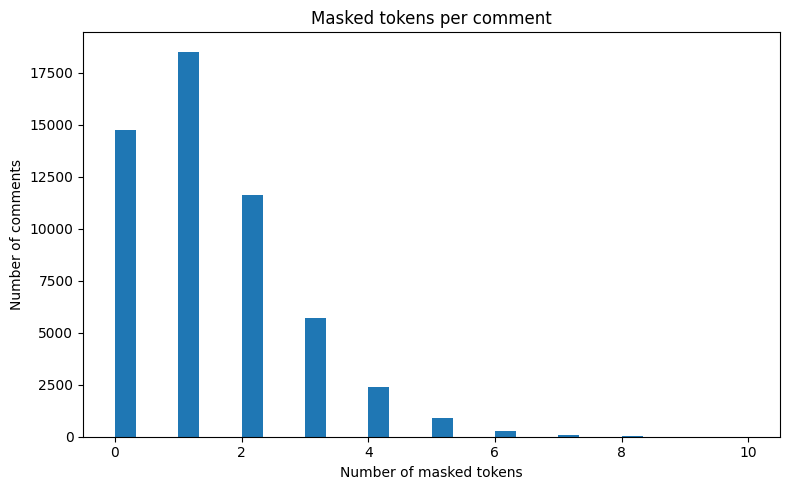

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(analysis_df["n_masked"], bins=30)
plt.title("Masked tokens per comment")
plt.xlabel("Number of masked tokens")
plt.ylabel("Number of comments")
plt.tight_layout()
plt.show()

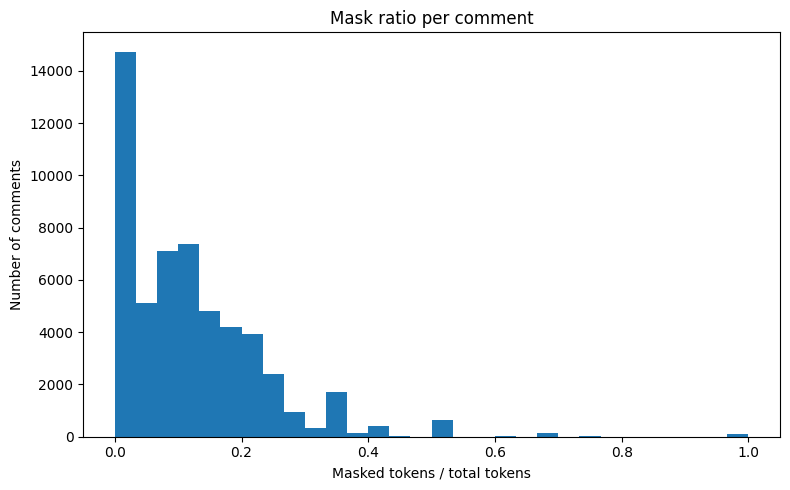

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(analysis_df["mask_ratio"], bins=30)
plt.title("Mask ratio per comment")
plt.xlabel("Masked tokens / total tokens")
plt.ylabel("Number of comments")
plt.tight_layout()
plt.show()

In [11]:
all_masked_terms_lower = [
    tok.lower()
    for row in analysis_df["masked_terms"]
    for tok in row
]

masked_term_counts = Counter(all_masked_terms_lower)

top_n = 25
top_terms_df = pd.DataFrame(
    masked_term_counts.most_common(top_n),
    columns=["term", "count"]
)

display(top_terms_df)

,term,count
0,love,2384
1,good,2153
2,time,1469
3,hope,970
4,bad,954
5,don,815
6,pretty,778
7,thought,716
8,happy,709
9,glad,557


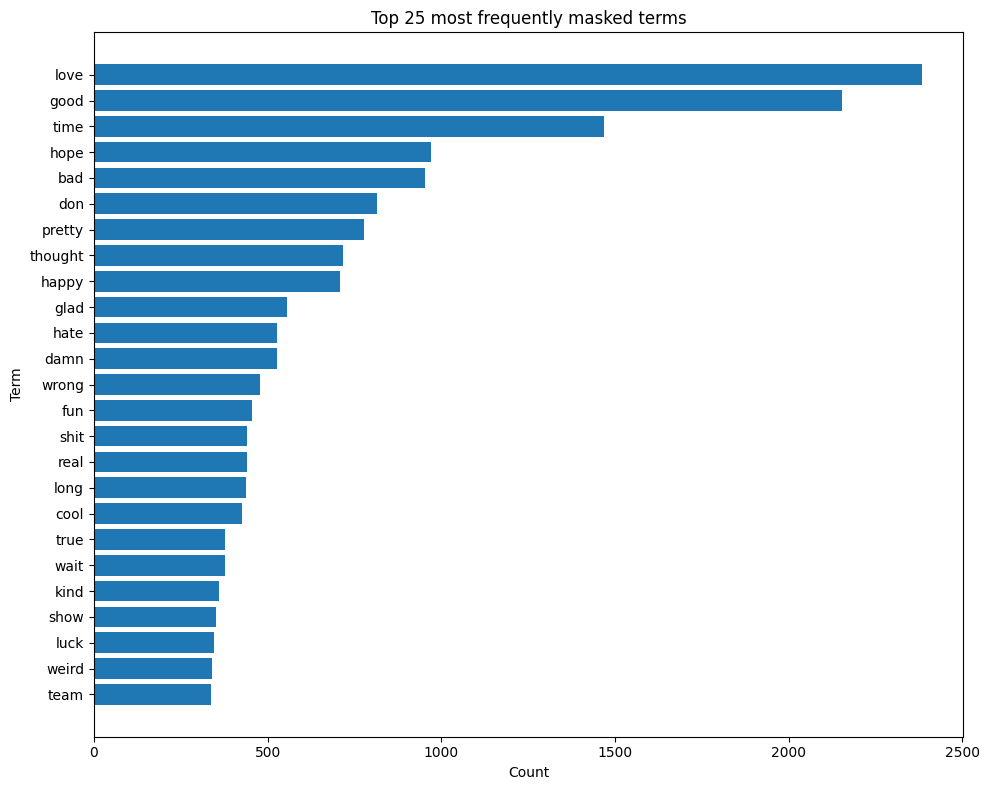

In [12]:
plt.figure(figsize=(10, 8))
plt.barh(top_terms_df["term"][::-1], top_terms_df["count"][::-1])
plt.title(f"Top {top_n} most frequently masked terms")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

In [13]:
label_counter = Counter()

for text in tqdm(analysis_df["text"], desc="Collecting NRC labels"):
    for _, _, labels in extract_token_labels(text):
        label_counter.update(labels)

label_df = pd.DataFrame(
    label_counter.most_common(),
    columns=["label", "count"]
)

display(label_df)

,label,count
0,positive,36579
1,negative,27698
2,trust,22357
3,anticipation,19744
4,joy,19486
5,fear,14918
6,anger,13749
7,sadness,13727
8,disgust,11238
9,surprise,10203


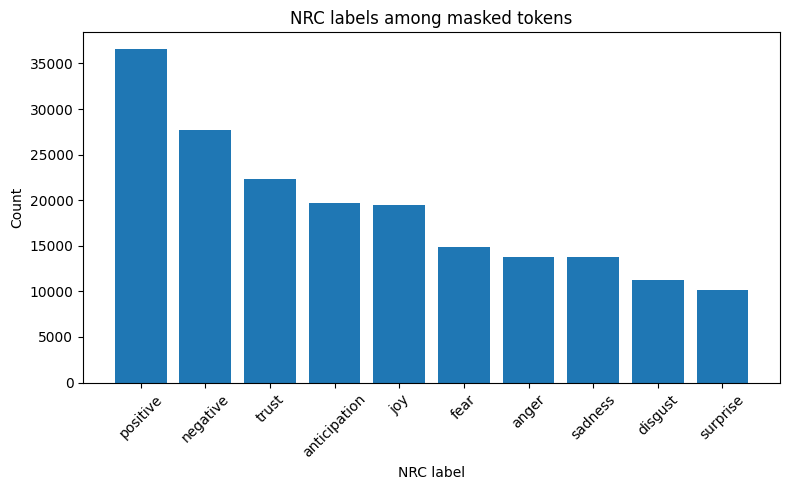

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(label_df["label"], label_df["count"])
plt.title("NRC labels among masked tokens")
plt.xlabel("NRC label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

pos_rows = []

for doc in tqdm(
    nlp.pipe(analysis_df["text"].tolist(), batch_size=256),
    total=len(analysis_df),
    desc="POS tagging"
):
    for tok in doc:
        if tok.is_space or tok.is_punct:
            continue
        if is_emotion_token(tok.text):
            pos_rows.append(
                {
                    "token": tok.text,
                    "token_lower": tok.text.lower(),
                    "lemma": tok.lemma_.lower(),
                    "pos": tok.pos_,
                    "tag": tok.tag_
                }
            )

pos_df = pd.DataFrame(pos_rows)

print("Number of masked token occurrences with POS:", len(pos_df))
display(pos_df.head())

POS tagging:   0%|          | 0/54263 [00:00<?, ?it/s]

Number of masked token occurrences with POS: 74323


,token,token_lower,lemma,pos,tag
0,food,food,food,NOUN,NN
1,laugh,laugh,laugh,NOUN,NN
2,Dirty,dirty,dirty,ADJ,JJ
3,gOoD,good,good,ADJ,JJ
4,wait,wait,wait,VERB,VB


In [16]:
pos_counts = pos_df["pos"].value_counts().rename_axis("pos").reset_index(name="count")
display(pos_counts)

,pos,count
0,NOUN,28049
1,ADJ,21205
2,VERB,19265
3,PROPN,2722
4,ADV,2540
5,INTJ,516
6,ADP,12
7,DET,4
8,X,3
9,NUM,2


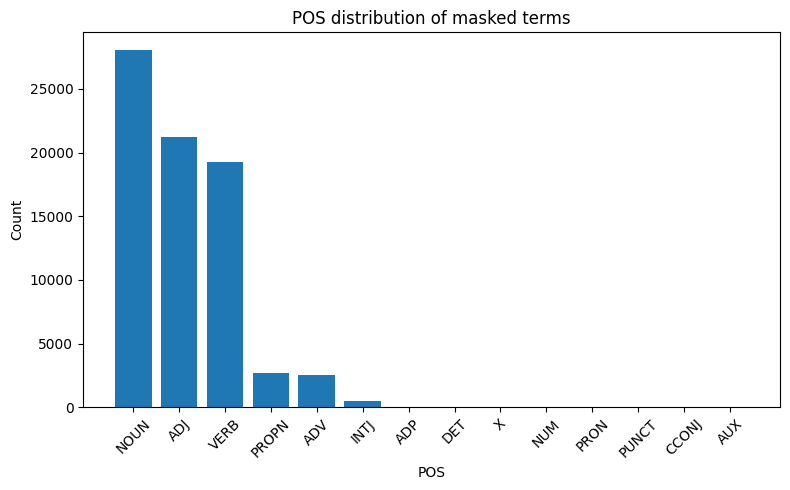

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(pos_counts["pos"], pos_counts["count"])
plt.title("POS distribution of masked terms")
plt.xlabel("POS")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
term_pos_counts = (
    pos_df.groupby(["token_lower", "pos"])
    .size()
    .reset_index(name="count")
    .sort_values(["token_lower", "count"], ascending=[True, False])
)

dominant_pos_df = (
    term_pos_counts.groupby("token_lower", as_index=False)
    .first()
    .rename(columns={"count": "dominant_pos_count"})
)

top_terms_with_pos = top_terms_df.merge(
    dominant_pos_df,
    left_on="term",
    right_on="token_lower",
    how="left"
)[["term", "count", "pos", "dominant_pos_count"]]

display(top_terms_with_pos)

,term,count,pos,dominant_pos_count
0,love,2384,VERB,1996
1,good,2153,ADJ,2093
2,time,1469,NOUN,1463
3,hope,970,VERB,850
4,bad,954,ADJ,937
5,don,815,PROPN,2
6,pretty,778,ADV,723
7,thought,716,VERB,608
8,happy,709,ADJ,653
9,glad,557,ADJ,480


### Notes
Some masked words do not carry any emotional meaning (like "thought" and "team"); we should consider manually removing them from the lexicon for the evaluation

In [19]:
high_mask_df = (
    analysis_df[["text", "masked_text", "masked_terms", "n_tokens", "n_masked", "mask_ratio", "split"]]
    .sort_values(["mask_ratio", "n_masked"], ascending=[False, False])
    .head(20)
)

display(high_mask_df)

,text,masked_text,masked_terms,n_tokens,n_masked,mask_ratio,split
33939,Sweet mother sweet mother,,"[Sweet, mother, sweet, mother]",4,4,1.0,train
172,good luck buddy,,"[good, luck, buddy]",3,3,1.0,train
5124,Hungry hungry hungry,,"[Hungry, hungry, hungry]",3,3,1.0,train
7316,"Money, money, money!",,"[Money, money, money]",3,3,1.0,train
12755,Good luck buddy!,,"[Good, luck, buddy]",3,3,1.0,train
13318,cool buzz words,,"[cool, buzz, words]",3,3,1.0,train
16152,Good luck mate!,,"[Good, luck, mate]",3,3,1.0,train
35994,Good luck friend.,,"[Good, luck, friend]",3,3,1.0,train
42382,Good job partner!,,"[Good, job, partner]",3,3,1.0,train
47949,Good job fatty!,,"[Good, job, fatty]",3,3,1.0,validation


# Pair comparison

In [20]:
N_PAIRS = 10000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)
n = len(analysis_df)

left_idx = rng.integers(0, n, size=N_PAIRS)
right_idx = rng.integers(0, n, size=N_PAIRS)

same = left_idx == right_idx
while same.any():
    right_idx[same] = rng.integers(0, n, size=same.sum())
    same = left_idx == right_idx

pair_df = pd.DataFrame(
    {
        "left_idx": left_idx,
        "right_idx": right_idx,
        "left_text": analysis_df.loc[left_idx, "text"].values,
        "right_text": analysis_df.loc[right_idx, "text"].values,
        "left_masked": analysis_df.loc[left_idx, "masked_text"].values,
        "right_masked": analysis_df.loc[right_idx, "masked_text"].values,
    }
)

display(pair_df.head())

,left_idx,right_idx,left_text,right_text,left_masked,right_masked
0,4843,18378,She sends it to her tinder dates as proof of i...,[NAME] living in y’all heads rent free lol. It...,She sends it to her tinder dates as of identit...,NAME living in y all heads rent free lol It s ...
1,41997,11837,I don't live there just have family there.,Nice! I’m glad you liked it. Have fun explorin...,I don't live there just have family there,Nice I m you liked it Have exploring
2,35519,28235,Thanks for this. I appreciate everyone involved.,"Riiiiight... your ""friend""...",Thanks for this I appreciate everyone involved,Riiiiight your
3,23814,35972,"Oh, fair enough. Praise be.",That and useful idiots.,Oh enough be,That and useful idiots
4,23496,14185,I feel this but I also sympathize with mentalc...,Lopez is a better rim protector but I get your...,I feel this but I also with mentalcels because...,Lopez is a better rim but I get your point


In [21]:
model = SentenceTransformer("all-MiniLM-L6-v2")

left_emb = model.encode(pair_df["left_text"].tolist(), convert_to_tensor=True, show_progress_bar=True)
right_emb = model.encode(pair_df["right_text"].tolist(), convert_to_tensor=True, show_progress_bar=True)

left_masked_emb = model.encode(pair_df["left_masked"].tolist(), convert_to_tensor=True, show_progress_bar=True)
right_masked_emb = model.encode(pair_df["right_masked"].tolist(), convert_to_tensor=True, show_progress_bar=True)

pair_df["raw_similarity"] = [
    util.cos_sim(left_emb[i], right_emb[i]).item()
    for i in range(len(pair_df))
]

pair_df["masked_similarity"] = [
    util.cos_sim(left_masked_emb[i], right_masked_emb[i]).item()
    for i in range(len(pair_df))
]

pair_df["similarity_delta"] = pair_df["masked_similarity"] - pair_df["raw_similarity"]

display(pair_df.head())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

,left_idx,right_idx,left_text,right_text,left_masked,right_masked,raw_similarity,masked_similarity,similarity_delta
0,4843,18378,She sends it to her tinder dates as proof of i...,[NAME] living in y’all heads rent free lol. It...,She sends it to her tinder dates as of identit...,NAME living in y all heads rent free lol It s ...,0.086087,0.050586,-0.035501
1,41997,11837,I don't live there just have family there.,Nice! I’m glad you liked it. Have fun explorin...,I don't live there just have family there,Nice I m you liked it Have exploring,-0.023635,0.045679,0.069314
2,35519,28235,Thanks for this. I appreciate everyone involved.,"Riiiiight... your ""friend""...",Thanks for this I appreciate everyone involved,Riiiiight your,0.123739,0.130025,0.006286
3,23814,35972,"Oh, fair enough. Praise be.",That and useful idiots.,Oh enough be,That and useful idiots,0.175743,0.214909,0.039166
4,23496,14185,I feel this but I also sympathize with mentalc...,Lopez is a better rim protector but I get your...,I feel this but I also with mentalcels because...,Lopez is a better rim but I get your point,0.038098,0.098085,0.059988


In [22]:
similarity_summary = pd.DataFrame(
    {
        "metric": [
            "Mean raw similarity",
            "Median raw similarity",
            "Mean masked similarity",
            "Median masked similarity",
            "Mean masked - raw delta",
            "Min raw similarity",
            "Max raw similarity",
            "Min masked similarity",
            "Max masked similarity",
        ],
        "value": [
            pair_df["raw_similarity"].mean(),
            pair_df["raw_similarity"].median(),
            pair_df["masked_similarity"].mean(),
            pair_df["masked_similarity"].median(),
            pair_df["similarity_delta"].mean(),
            pair_df["raw_similarity"].min(),
            pair_df["raw_similarity"].max(),
            pair_df["masked_similarity"].min(),
            pair_df["masked_similarity"].max(),
        ]
    }
)

display(similarity_summary)

,metric,value
0,Mean raw similarity,0.077378
1,Median raw similarity,0.072032
2,Mean masked similarity,0.094722
3,Median masked similarity,0.090490
4,Mean masked - raw delta,0.017344
5,Min raw similarity,-0.202201
6,Max raw similarity,0.644081
7,Min masked similarity,-0.198811
8,Max masked similarity,0.529741


### Notes
On average, all comments are very distant meaning-wise: this suggest the dataset has a wide variety of meaning

Score column: masked_similarity
Total edges in pair_df: 10000
Edge-sampled edges (30%): 10000
Sampled nodes (30%): 54263 out of 54263
Edges retained after node sampling: 10000


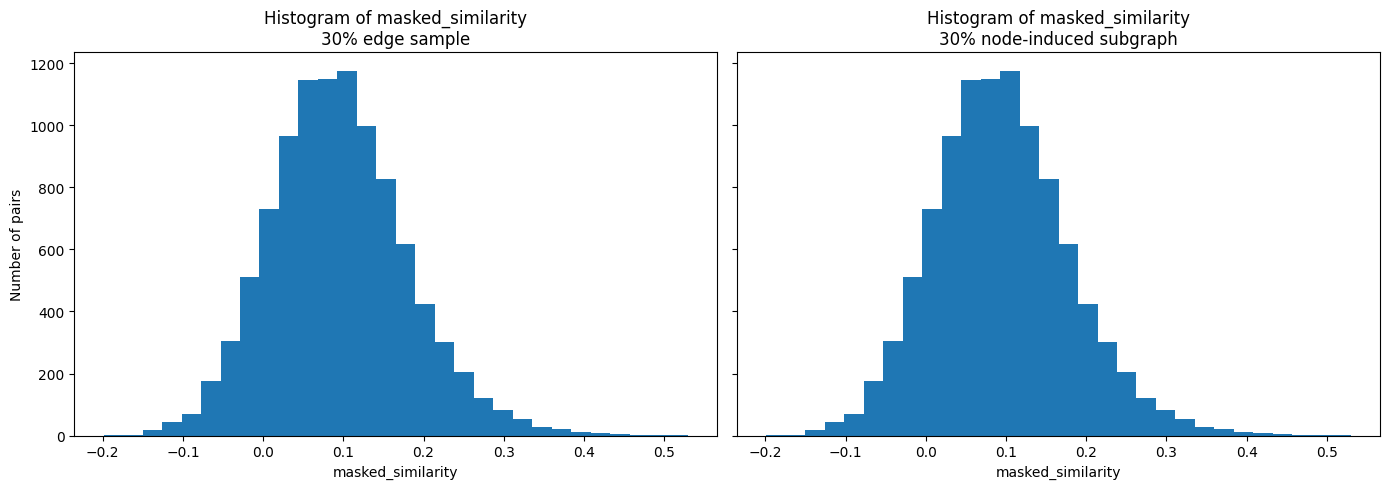

In [23]:
# Histogram of similarity scores under:
# 1) random edge sampling (30% of edges)
# 2) random node sampling (30% of nodes, then keep only edges between sampled nodes)

score_col = "masked_similarity"   # change to "raw_similarity" if you want
sample_frac = 1.0
random_seed = 42 

# --- 1) Edge sampling: sample 30% of the existing edges directly ---
edge_sample_df = pair_df.sample(frac=sample_frac, random_state=random_seed).copy()

# --- 2) Node sampling: sample 30% of nodes, then keep only edges internal to that node set ---
all_nodes = np.arange(len(analysis_df))
rng = np.random.default_rng(random_seed)

n_sample_nodes = max(1, int(len(all_nodes) * sample_frac))
sampled_nodes = set(rng.choice(all_nodes, size=n_sample_nodes, replace=False))

node_sample_df = pair_df[
    pair_df["left_idx"].isin(sampled_nodes) & pair_df["right_idx"].isin(sampled_nodes)
].copy()

print(f"Score column: {score_col}")
print(f"Total edges in pair_df: {len(pair_df)}")
print(f"Edge-sampled edges (30%): {len(edge_sample_df)}")
print(f"Sampled nodes (30%): {len(sampled_nodes)} out of {len(all_nodes)}")
print(f"Edges retained after node sampling: {len(node_sample_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(edge_sample_df[score_col], bins=30)
axes[0].set_title(f"Histogram of {score_col}\n30% edge sample")
axes[0].set_xlabel(score_col)
axes[0].set_ylabel("Number of pairs")

axes[1].hist(node_sample_df[score_col], bins=30)
axes[1].set_title(f"Histogram of {score_col}\n30% node-induced subgraph")
axes[1].set_xlabel(score_col)

plt.tight_layout()
plt.show()

# Single label comparison

In [24]:
label_indicator_cols = [col for col in label_cols if col in goemotions_df.columns]

neutral_col = next((col for col in label_indicator_cols if col.lower() == "neutral"), None)

single_label_df = goemotions_df[[text_col, "split"] + label_indicator_cols].copy()
single_label_df = single_label_df.rename(columns={text_col: "text"})
single_label_df["text"] = single_label_df["text"].astype(str)
single_label_df = single_label_df[single_label_df["text"].str.strip() != ""].copy()

# Keep only comments with exactly one active label
single_label_df["label_count"] = single_label_df[label_indicator_cols].sum(axis=1)
single_label_df = single_label_df[single_label_df["label_count"] == 1].copy()

# Recover the unique active label
single_label_df["single_label"] = single_label_df[label_indicator_cols].idxmax(axis=1)

# Exclude neutral
if neutral_col is not None:
    single_label_df = single_label_df[single_label_df["single_label"] != neutral_col].copy()

single_label_df = single_label_df.reset_index(drop=True)

# Build masked text for the subset
single_label_df["masked_text"] = single_label_df["text"].progress_apply(mask_text_with_nrclex)

print("Single-label, non-neutral comments:", len(single_label_df))
print("Unique labels in subset:", single_label_df["single_label"].nunique())
display(single_label_df[["text", "masked_text", "single_label", "split"]].head())

  0%|          | 0/29425 [00:00<?, ?it/s]

Single-label, non-neutral comments: 29425
Unique labels in subset: 27


,text,masked_text,single_label,split
0,WHY THE FUCK IS BAYLESS ISOING,WHY THE FUCK IS BAYLESS ISOING,anger,train
1,To make her feel threatened,To make her feel threatened,fear,train
2,Dirty Southern Wankers,Southern Wankers,annoyance,train
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,OmG pEyToN iSn'T eNoUgH tO hElP uS iN tHe PlAy...,surprise,train
4,Yes I heard abt the f bombs! That has to be wh...,Yes I heard abt the f bombs That has to be why...,gratitude,train


,label,n_comments
0,admiration,3384
1,gratitude,2378
2,approval,2367
3,amusement,2046
4,annoyance,1809
5,disapproval,1809
6,love,1760
7,curiosity,1729
8,anger,1265
9,optimism,1087


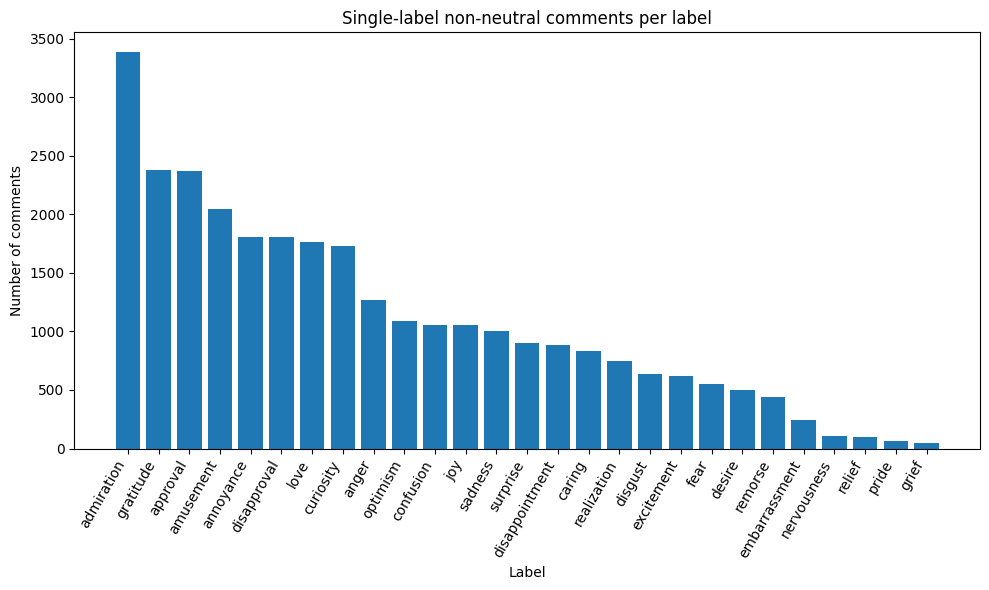

In [25]:
single_label_counts = (
    single_label_df["single_label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="n_comments")
)

display(single_label_counts)

plt.figure(figsize=(10, 6))
plt.bar(single_label_counts["label"], single_label_counts["n_comments"])
plt.title("Single-label non-neutral comments per label")
plt.xlabel("Label")
plt.ylabel("Number of comments")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [26]:
import torch
import torch.nn.functional as F

if "model" not in globals():
    model = SentenceTransformer("all-MiniLM-L6-v2")

single_label_raw_emb = model.encode(
    single_label_df["text"].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
)

single_label_masked_emb = model.encode(
    single_label_df["masked_text"].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Raw embedding shape:", tuple(single_label_raw_emb.shape))
print("Masked embedding shape:", tuple(single_label_masked_emb.shape))

Batches:   0%|          | 0/920 [00:00<?, ?it/s]

Batches:   0%|          | 0/920 [00:00<?, ?it/s]

Raw embedding shape: (29425, 384)
Masked embedding shape: (29425, 384)


In [27]:
import math

def sample_unordered_pairs(indices, max_pairs, rng):
    """
    Sample up to max_pairs unique unordered pairs from a list/array of indices.
    Returns a list of (i, j) with i != j.
    """
    indices = np.asarray(indices)
    n = len(indices)

    if n < 2:
        return []

    total_possible = n * (n - 1) // 2
    target = min(max_pairs, total_possible)

    # For small groups, enumerate all pairs exactly
    if total_possible <= target:
        out = []
        for a in range(n):
            for b in range(a + 1, n):
                out.append((indices[a], indices[b]))
        return out

    # Otherwise sample unique unordered pairs
    pairs = set()
    while len(pairs) < target:
        a, b = rng.choice(indices, size=2, replace=False)
        if a > b:
            a, b = b, a
        pairs.add((int(a), int(b)))

    return list(pairs)


max_pairs_per_label = 3000
random_seed = 42
rng = np.random.default_rng(random_seed)

pair_frames = []

for label, group in single_label_df.groupby("single_label", sort=True):
    group_indices = group.index.to_numpy()
    sampled_pairs = sample_unordered_pairs(group_indices, max_pairs_per_label, rng)

    if len(sampled_pairs) == 0:
        continue

    left_idx = torch.tensor([i for i, j in sampled_pairs], dtype=torch.long)
    right_idx = torch.tensor([j for i, j in sampled_pairs], dtype=torch.long)

    raw_sim = F.cosine_similarity(
        single_label_raw_emb[left_idx],
        single_label_raw_emb[right_idx],
        dim=1
    ).cpu().numpy()

    masked_sim = F.cosine_similarity(
        single_label_masked_emb[left_idx],
        single_label_masked_emb[right_idx],
        dim=1
    ).cpu().numpy()

    frame = pd.DataFrame(
        {
            "label": label,
            "left_idx": left_idx.cpu().numpy(),
            "right_idx": right_idx.cpu().numpy(),
            "raw_similarity": raw_sim,
            "masked_similarity": masked_sim,
            "group_size": len(group),
            "n_sampled_pairs": len(sampled_pairs),
        }
    )
    pair_frames.append(frame)

label_pair_df = pd.concat(pair_frames, ignore_index=True)

print("Total within-label sampled pairs:", len(label_pair_df))
display(label_pair_df.head())

Total within-label sampled pairs: 78292


,label,left_idx,right_idx,raw_similarity,masked_similarity,group_size,n_sampled_pairs
0,admiration,15897,21853,0.342936,0.334508,3384,3000
1,admiration,4761,23524,0.233458,0.120612,3384,3000
2,admiration,4298,18015,0.017809,0.080661,3384,3000
3,admiration,15364,27397,-0.043426,0.030168,3384,3000
4,admiration,11814,12771,-0.031167,0.005052,3384,3000


In [28]:
label_similarity_summary = (
    label_pair_df
    .groupby("label")
    .agg(
        n_pairs=("masked_similarity", "size"),
        mean_raw_similarity=("raw_similarity", "mean"),
        median_raw_similarity=("raw_similarity", "median"),
        mean_masked_similarity=("masked_similarity", "mean"),
        median_masked_similarity=("masked_similarity", "median"),
        std_masked_similarity=("masked_similarity", "std"),
        group_size=("group_size", "first"),
    )
    .reset_index()
    .sort_values("mean_masked_similarity", ascending=False)
)

display(label_similarity_summary)

,label,n_pairs,mean_raw_similarity,median_raw_similarity,mean_masked_similarity,median_masked_similarity,std_masked_similarity,group_size
16,grief,1081,0.215330,0.206494,0.196364,0.182280,0.119782,47
15,gratitude,3000,0.160469,0.153784,0.189809,0.179689,0.116210,2378
24,remorse,3000,0.147766,0.135633,0.176662,0.166731,0.110607,437
1,amusement,3000,0.137262,0.133431,0.150737,0.147554,0.091119,2046
14,fear,3000,0.162371,0.152006,0.137380,0.125755,0.106684,553
25,sadness,3000,0.135636,0.129943,0.136041,0.127669,0.099943,1003
18,love,3000,0.147469,0.138690,0.134945,0.128574,0.100330,1760
8,desire,3000,0.115489,0.106139,0.134416,0.123947,0.106347,497
2,anger,3000,0.126818,0.121418,0.130905,0.123434,0.087442,1265
21,pride,2211,0.156202,0.134783,0.126736,0.119479,0.094954,67


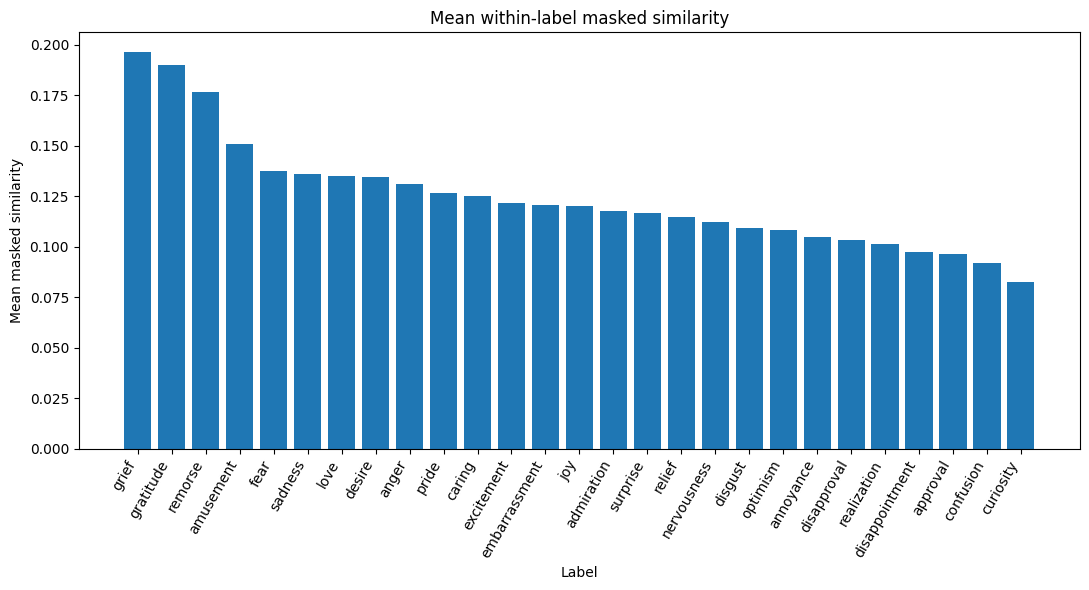

In [29]:
plt.figure(figsize=(11, 6))
plt.bar(label_similarity_summary["label"], label_similarity_summary["mean_masked_similarity"])
plt.title("Mean within-label masked similarity")
plt.xlabel("Label")
plt.ylabel("Mean masked similarity")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

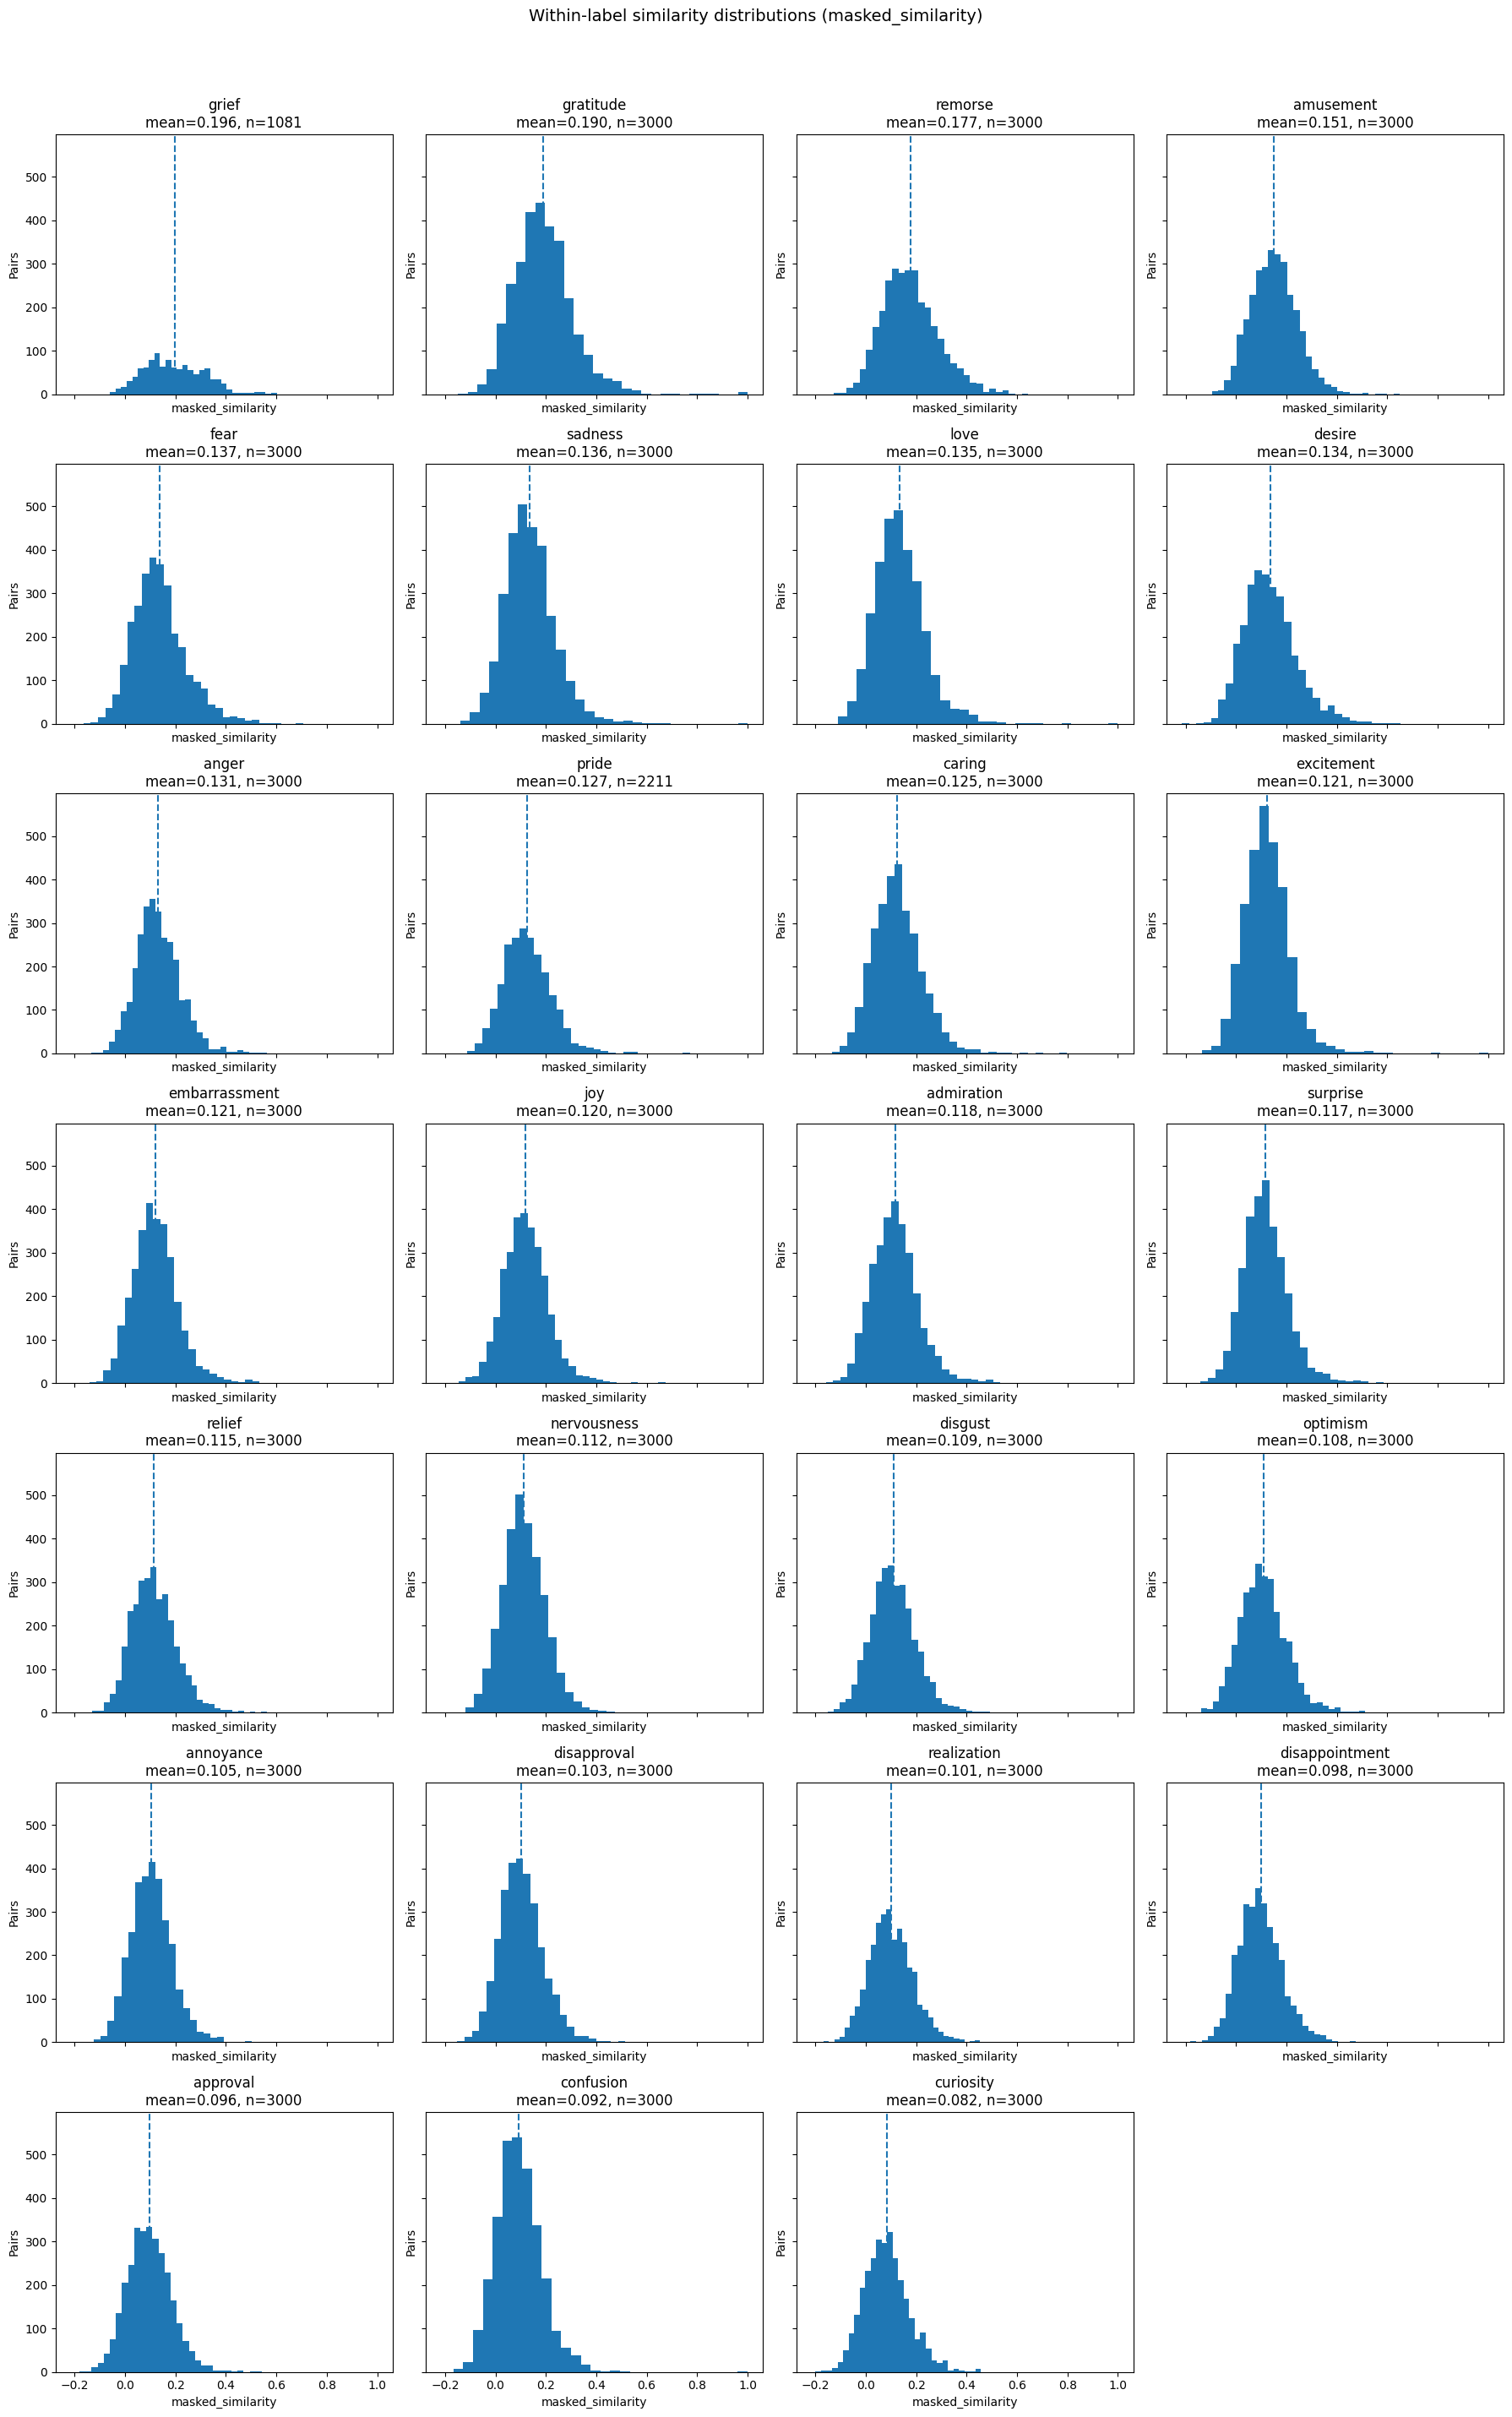

In [30]:
score_col = "masked_similarity"   # change to "raw_similarity" if needed

labels_in_order = label_similarity_summary["label"].tolist()

n_labels = len(labels_in_order)
n_cols = 4
n_rows = math.ceil(n_labels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, label in zip(axes, labels_in_order):
    subset = label_pair_df[label_pair_df["label"] == label]

    ax.hist(subset[score_col], bins=30)
    ax.axvline(subset[score_col].mean(), linestyle="--")
    ax.set_title(f"{label}\nmean={subset[score_col].mean():.3f}, n={len(subset)}")
    ax.set_xlabel(score_col)
    ax.set_ylabel("Pairs")

# Hide any unused axes
for ax in axes[n_labels:]:
    ax.axis("off")

plt.suptitle(f"Within-label similarity distributions ({score_col})", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

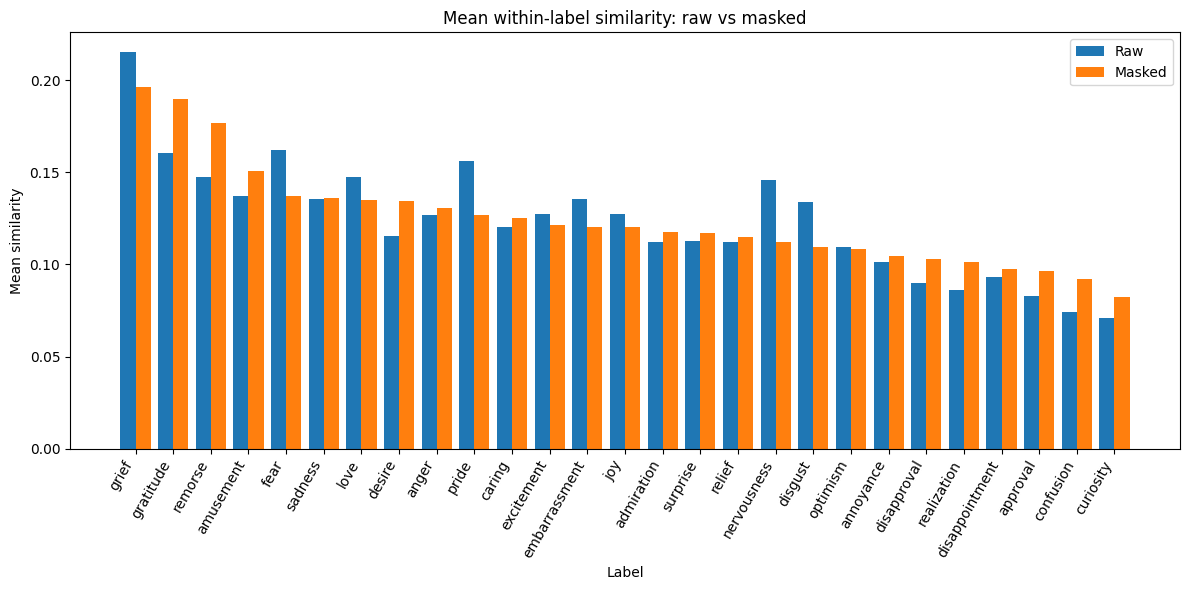

In [31]:
compare_df = label_similarity_summary.sort_values("mean_masked_similarity", ascending=False)

x = np.arange(len(compare_df))
width = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, compare_df["mean_raw_similarity"], width=width, label="Raw")
plt.bar(x + width/2, compare_df["mean_masked_similarity"], width=width, label="Masked")

plt.title("Mean within-label similarity: raw vs masked")
plt.xlabel("Label")
plt.ylabel("Mean similarity")
plt.xticks(x, compare_df["label"], rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Notes
It seems like masking flattens the similarity. Corroborated below

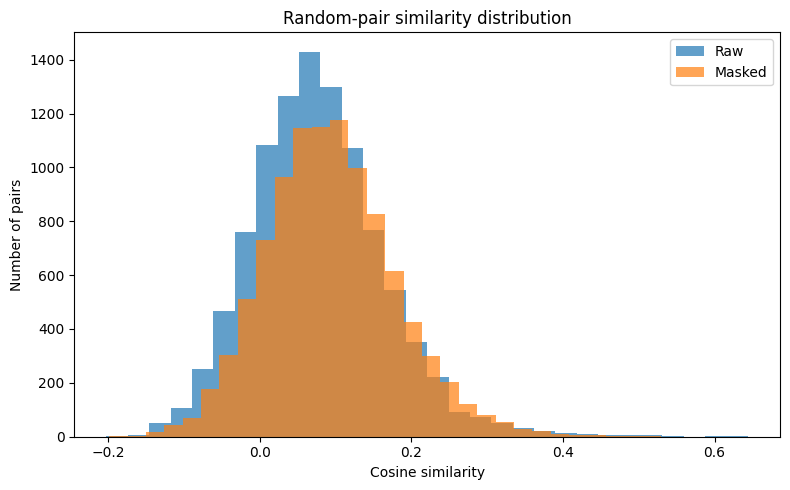

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(pair_df["raw_similarity"], bins=30, alpha=0.7, label="Raw")
plt.hist(pair_df["masked_similarity"], bins=30, alpha=0.7, label="Masked")
plt.title("Random-pair similarity distribution")
plt.xlabel("Cosine similarity")
plt.ylabel("Number of pairs")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
display(
    label_similarity_summary[
        ["label", "group_size", "n_pairs", "mean_raw_similarity", "mean_masked_similarity", "std_masked_similarity"]
    ]
    .sort_values("mean_masked_similarity", ascending=False)
)

,label,group_size,n_pairs,mean_raw_similarity,mean_masked_similarity,std_masked_similarity
16,grief,47,1081,0.215330,0.196364,0.119782
15,gratitude,2378,3000,0.160469,0.189809,0.116210
24,remorse,437,3000,0.147766,0.176662,0.110607
1,amusement,2046,3000,0.137262,0.150737,0.091119
14,fear,553,3000,0.162371,0.137380,0.106684
25,sadness,1003,3000,0.135636,0.136041,0.099943
18,love,1760,3000,0.147469,0.134945,0.100330
8,desire,497,3000,0.115489,0.134416,0.106347
2,anger,1265,3000,0.126818,0.130905,0.087442
21,pride,67,2211,0.156202,0.126736,0.094954


,label,n_pairs,mean_before_std,std_before_std,emd_to_N01
0,amusement,3000,0.150737,0.091104,0.053531
1,nervousness,3000,0.112177,0.086177,0.054868
2,approval,3000,0.096217,0.087053,0.055784
3,realization,3000,0.101353,0.086989,0.061095
4,annoyance,3000,0.104752,0.082531,0.062561
5,disgust,3000,0.109286,0.089388,0.067241
6,disappointment,3000,0.097533,0.086262,0.072992
7,curiosity,3000,0.082314,0.089149,0.074843
8,optimism,3000,0.108242,0.093092,0.076438
9,joy,3000,0.120233,0.089844,0.077381


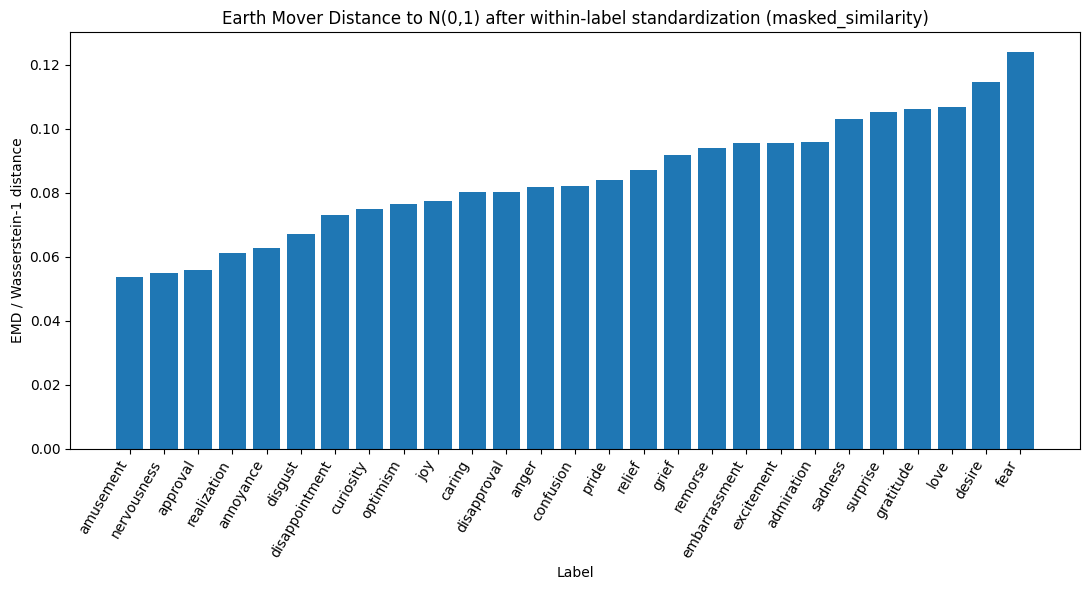

In [33]:
from scipy.stats import norm, wasserstein_distance

score_col = "masked_similarity"   # change to "raw_similarity" if needed

emd_rows = []
standardized_frames = []

for label, group in label_pair_df.groupby("label", sort=True):
    x = group[score_col].dropna().to_numpy()
    n = len(x)

    # Need at least 2 points and nonzero variance
    if n < 2:
        continue

    mu = x.mean()
    sigma = x.std(ddof=0)

    if sigma == 0:
        continue

    z = (x - mu) / sigma

    # Deterministic reference sample from N(0,1):
    # use equally spaced quantiles instead of random draws
    probs = (np.arange(n) + 0.5) / n
    normal_ref = norm.ppf(probs)

    emd = wasserstein_distance(np.sort(z), np.sort(normal_ref))

    emd_rows.append(
        {
            "label": label,
            "n_pairs": n,
            "mean_before_std": mu,
            "std_before_std": sigma,
            "emd_to_N01": emd
        }
    )

    standardized_frames.append(
        pd.DataFrame(
            {
                "label": label,
                "z_score": z
            }
        )
    )

emd_df = pd.DataFrame(emd_rows).sort_values("emd_to_N01", ascending=True).reset_index(drop=True)
zscore_df = pd.concat(standardized_frames, ignore_index=True)

display(emd_df)

plt.figure(figsize=(11, 6))
plt.bar(emd_df["label"], emd_df["emd_to_N01"])
plt.title(f"Earth Mover Distance to N(0,1) after within-label standardization ({score_col})")
plt.xlabel("Label")
plt.ylabel("EMD / Wasserstein-1 distance")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

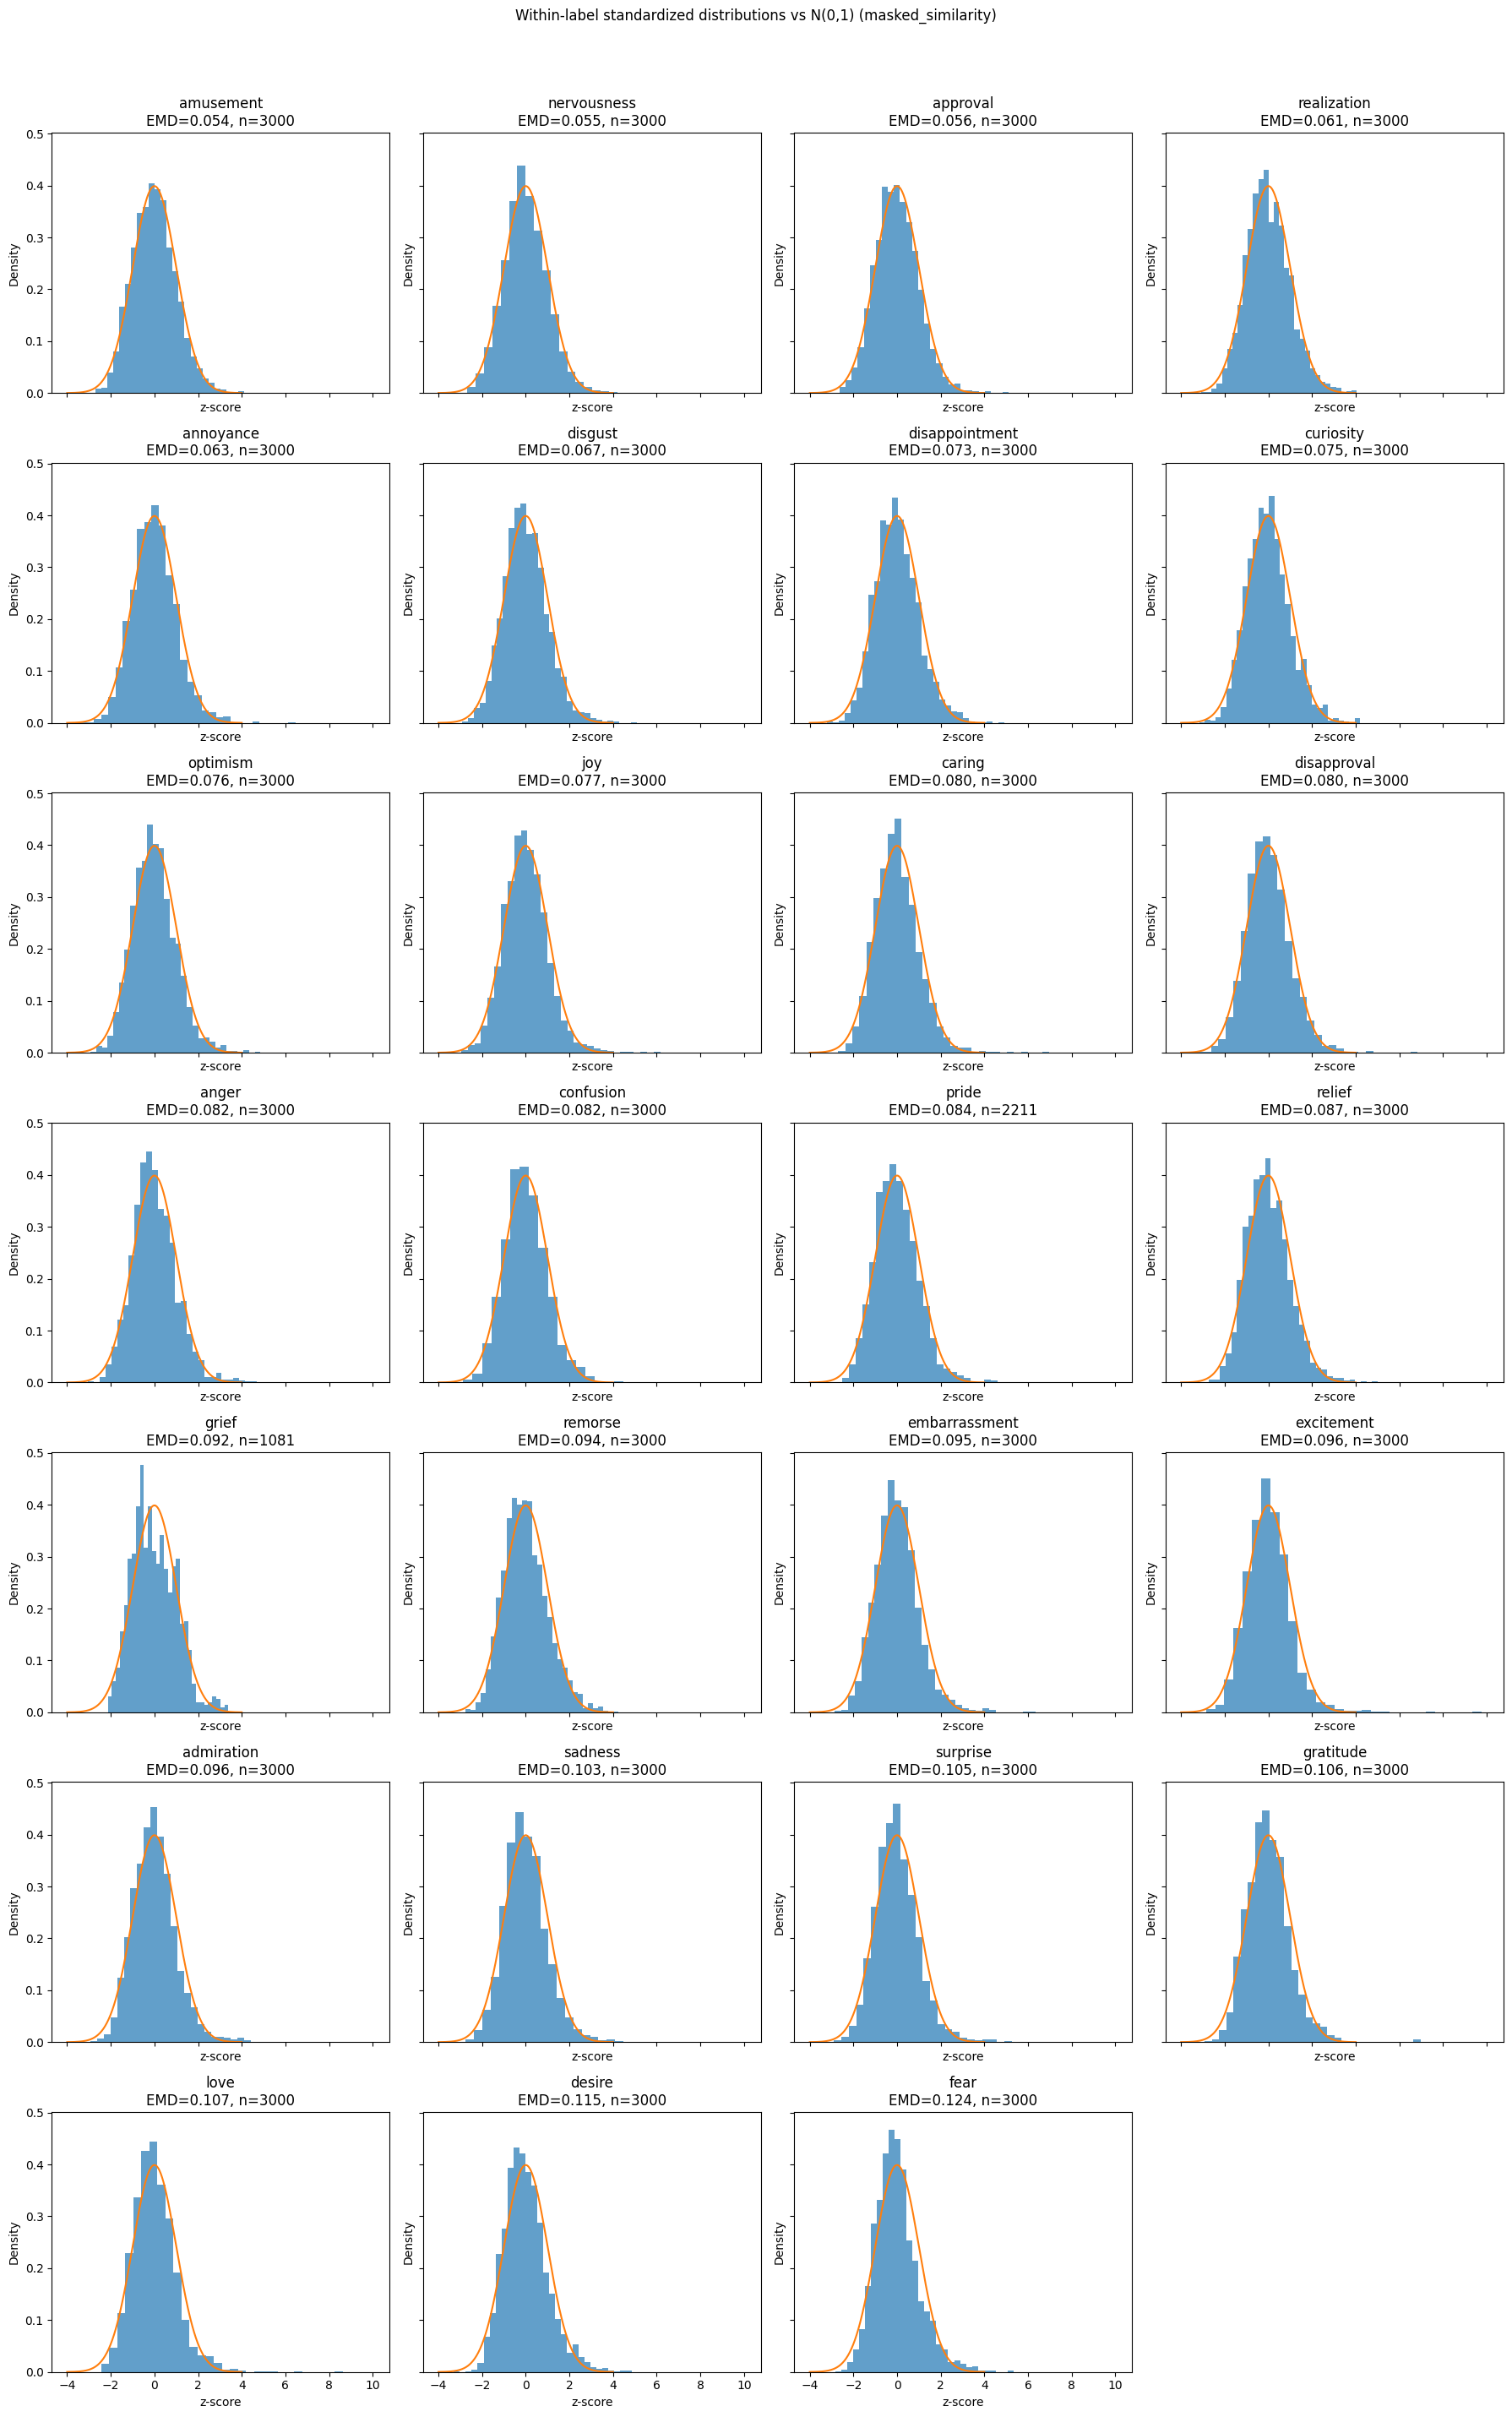

In [34]:
labels_in_order = emd_df["label"].tolist()

n_labels = len(labels_in_order)
n_cols = 4
n_rows = math.ceil(n_labels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

x_grid = np.linspace(-4, 4, 400)
normal_pdf = norm.pdf(x_grid)

for ax, label in zip(axes, labels_in_order):
    subset = zscore_df[zscore_df["label"] == label]["z_score"].to_numpy()

    ax.hist(subset, bins=30, density=True, alpha=0.7)
    ax.plot(x_grid, normal_pdf)
    emd_val = emd_df.loc[emd_df["label"] == label, "emd_to_N01"].iloc[0]

    ax.set_title(f"{label}\nEMD={emd_val:.3f}, n={len(subset)}")
    ax.set_xlabel("z-score")
    ax.set_ylabel("Density")

for ax in axes[n_labels:]:
    ax.axis("off")

plt.suptitle(f"Within-label standardized distributions vs N(0,1) ({score_col})", y=1.02)
plt.tight_layout()
plt.show()

,label,mean_masked_similarity,std_masked_similarity,emd_to_N01,group_size,n_pairs
0,grief,0.196364,0.119782,0.091701,47,1081
1,gratitude,0.189809,0.116210,0.106052,2378,3000
2,remorse,0.176662,0.110607,0.093944,437,3000
3,amusement,0.150737,0.091119,0.053531,2046,3000
4,fear,0.137380,0.106684,0.123945,553,3000
5,sadness,0.136041,0.099943,0.102996,1003,3000
6,love,0.134945,0.100330,0.106887,1760,3000
7,desire,0.134416,0.106347,0.114573,497,3000
8,anger,0.130905,0.087442,0.081886,1265,3000
9,pride,0.126736,0.094954,0.083842,67,2211


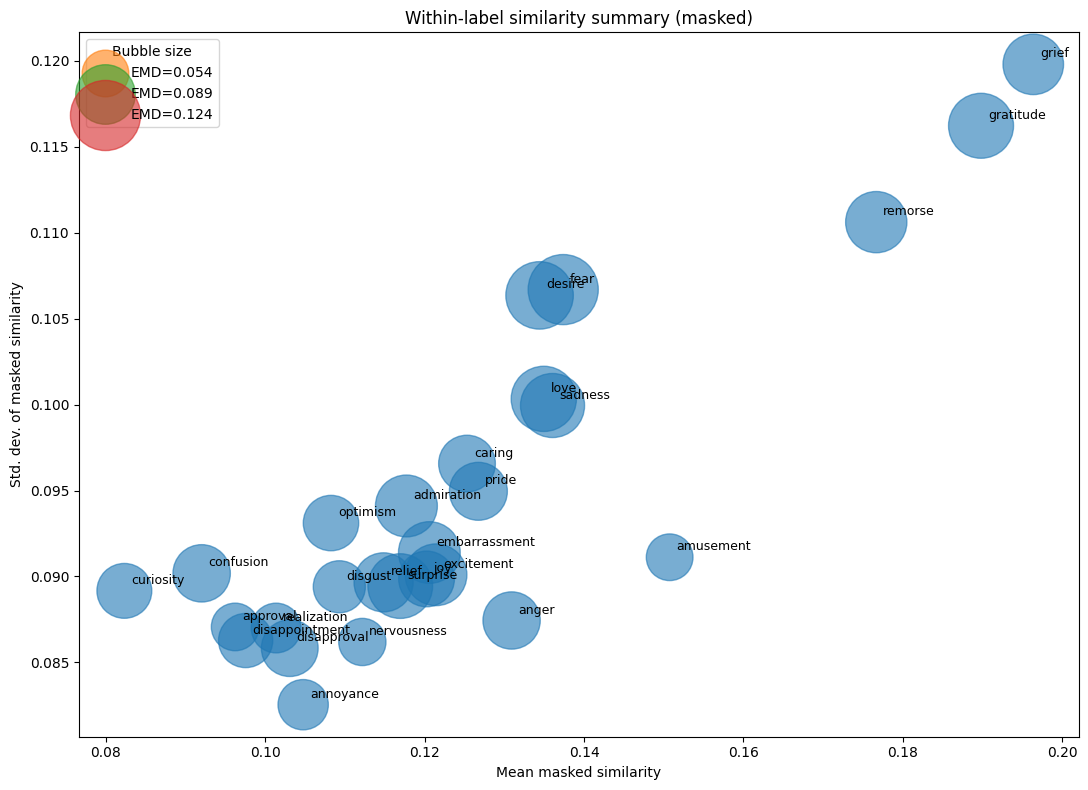

In [35]:
# Comprehensive scatter plot:
# x-axis  -> mean similarity
# y-axis  -> standard deviation of similarity
# size    -> EMD to N(0,1)

score_prefix = "masked"   # change to "raw" if you want raw_similarity statistics

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

# Scale bubble sizes for readability
size_scale = 2500
plot_df["bubble_size"] = (
    plot_df["emd_to_N01"] / plot_df["emd_to_N01"].max()
) * size_scale + 50

display(
    plot_df[
        ["label", mean_col, std_col, "emd_to_N01", "group_size", "n_pairs"]
    ].sort_values(mean_col, ascending=False)
)

plt.figure(figsize=(11, 8))

plt.scatter(
    plot_df[mean_col],
    plot_df[std_col],
    s=plot_df["bubble_size"],
    alpha=0.6
)

# Annotate each point with the label name
for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row[std_col]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Within-label similarity summary ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel(f"Std. dev. of {score_prefix} similarity")

# Optional legend for approximate point sizes
emd_vals = np.linspace(plot_df["emd_to_N01"].min(), plot_df["emd_to_N01"].max(), 3)
legend_sizes = (emd_vals / plot_df["emd_to_N01"].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.6, label=f"EMD={v:.3f}")
    for s, v in zip(legend_sizes, emd_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.tight_layout()
plt.show()

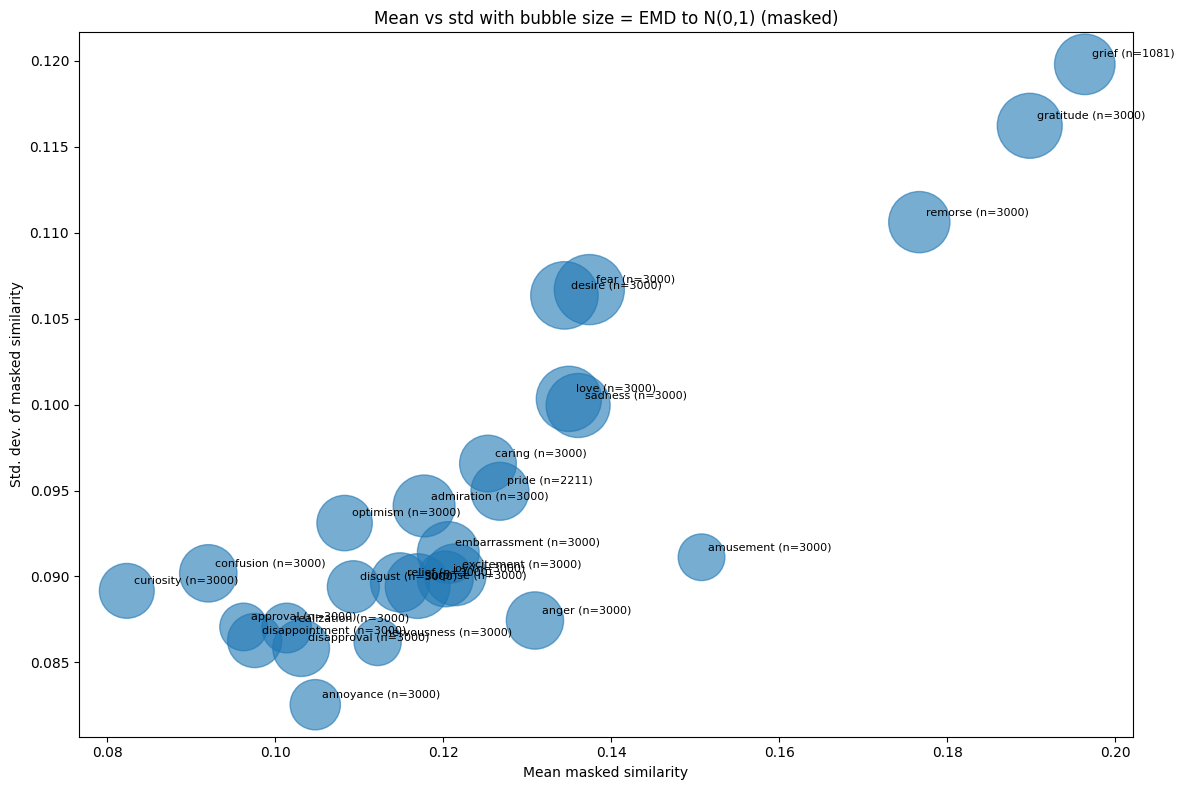

In [36]:
score_prefix = "masked"

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

size_scale = 2500
plot_df["bubble_size"] = (
    plot_df["emd_to_N01"] / plot_df["emd_to_N01"].max()
) * size_scale + 50

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_df[mean_col],
    plot_df[std_col],
    s=plot_df["bubble_size"],
    alpha=0.6
)

for _, row in plot_df.iterrows():
    plt.annotate(
        f"{row['label']} (n={row['n_pairs']})",
        (row[mean_col], row[std_col]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(f"Mean vs std with bubble size = EMD to N(0,1) ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel(f"Std. dev. of {score_prefix} similarity")
plt.tight_layout()
plt.show()

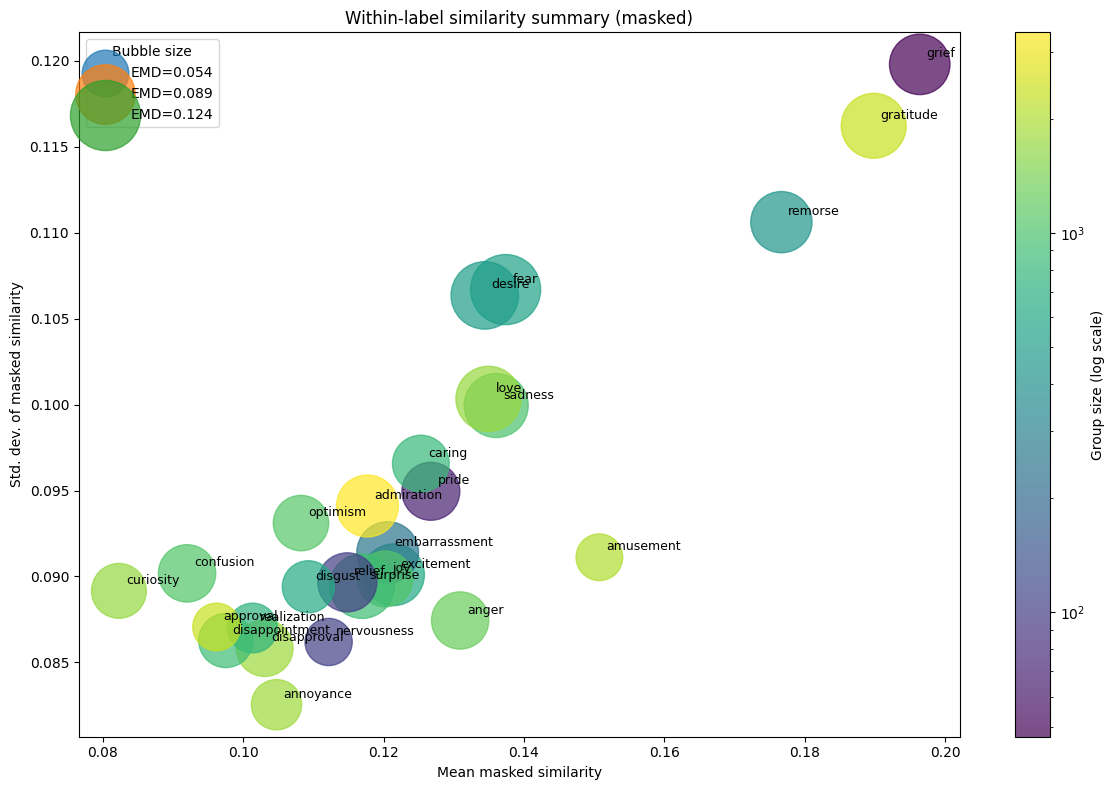

In [37]:
import matplotlib.colors as mcolors

score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

size_scale = 2500
plot_df["bubble_size"] = (
    plot_df["emd_to_N01"] / plot_df["emd_to_N01"].max()
) * size_scale + 50

plt.figure(figsize=(12, 8))

norm = mcolors.LogNorm(
    vmin=max(plot_df["group_size"].min(), 1),
    vmax=plot_df["group_size"].max()
)

scatter = plt.scatter(
    plot_df[mean_col],
    plot_df[std_col],
    s=plot_df["bubble_size"],
    c=plot_df["group_size"],
    norm=norm,
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row[std_col]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Within-label similarity summary ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel(f"Std. dev. of {score_prefix} similarity")

cbar = plt.colorbar(scatter)
cbar.set_label("Group size (log scale)")

emd_vals = np.linspace(plot_df["emd_to_N01"].min(), plot_df["emd_to_N01"].max(), 3)
legend_sizes = (emd_vals / plot_df["emd_to_N01"].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.7, label=f"EMD={v:.3f}")
    for s, v in zip(legend_sizes, emd_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.tight_layout()
plt.show()

,label,mean_masked_similarity,std_masked_similarity,emd_to_N01,group_size,n_pairs
0,grief,0.196364,0.119782,0.091701,47,1081
1,gratitude,0.189809,0.116210,0.106052,2378,3000
2,remorse,0.176662,0.110607,0.093944,437,3000
3,amusement,0.150737,0.091119,0.053531,2046,3000
4,fear,0.137380,0.106684,0.123945,553,3000
5,sadness,0.136041,0.099943,0.102996,1003,3000
6,love,0.134945,0.100330,0.106887,1760,3000
7,desire,0.134416,0.106347,0.114573,497,3000
8,anger,0.130905,0.087442,0.081886,1265,3000
9,pride,0.126736,0.094954,0.083842,67,2211


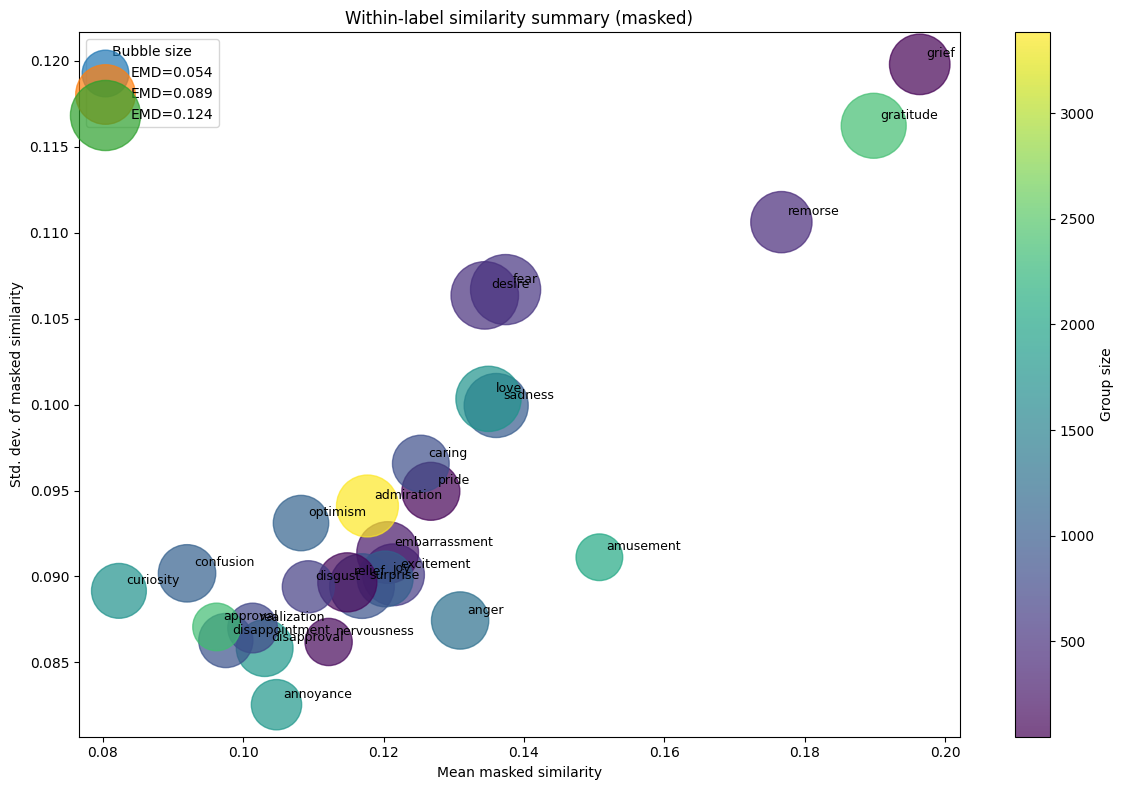

In [38]:
# Comprehensive scatter plot:
# x-axis     -> mean similarity
# y-axis     -> standard deviation of similarity
# bubble size  -> EMD to N(0,1)
# bubble color -> group size

score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

# Scale bubble sizes for readability
size_scale = 2500
plot_df["bubble_size"] = (
    plot_df["emd_to_N01"] / plot_df["emd_to_N01"].max()
) * size_scale + 50

display(
    plot_df[
        ["label", mean_col, std_col, "emd_to_N01", "group_size", "n_pairs"]
    ].sort_values(mean_col, ascending=False)
)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df[mean_col],
    plot_df[std_col],
    s=plot_df["bubble_size"],
    c=plot_df["group_size"],
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row[std_col]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Within-label similarity summary ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel(f"Std. dev. of {score_prefix} similarity")

cbar = plt.colorbar(scatter)
cbar.set_label("Group size")

# Bubble-size legend for EMD
emd_vals = np.linspace(plot_df["emd_to_N01"].min(), plot_df["emd_to_N01"].max(), 3)
legend_sizes = (emd_vals / plot_df["emd_to_N01"].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.7, label=f"EMD={v:.3f}")
    for s, v in zip(legend_sizes, emd_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.tight_layout()
plt.show()

,label,mean_masked_similarity,std_masked_similarity,emd_to_N01,group_size,n_pairs
0,grief,0.196364,0.119782,0.091701,47,1081
1,gratitude,0.189809,0.116210,0.106052,2378,3000
2,remorse,0.176662,0.110607,0.093944,437,3000
3,amusement,0.150737,0.091119,0.053531,2046,3000
4,fear,0.137380,0.106684,0.123945,553,3000
5,sadness,0.136041,0.099943,0.102996,1003,3000
6,love,0.134945,0.100330,0.106887,1760,3000
7,desire,0.134416,0.106347,0.114573,497,3000
8,anger,0.130905,0.087442,0.081886,1265,3000
9,pride,0.126736,0.094954,0.083842,67,2211


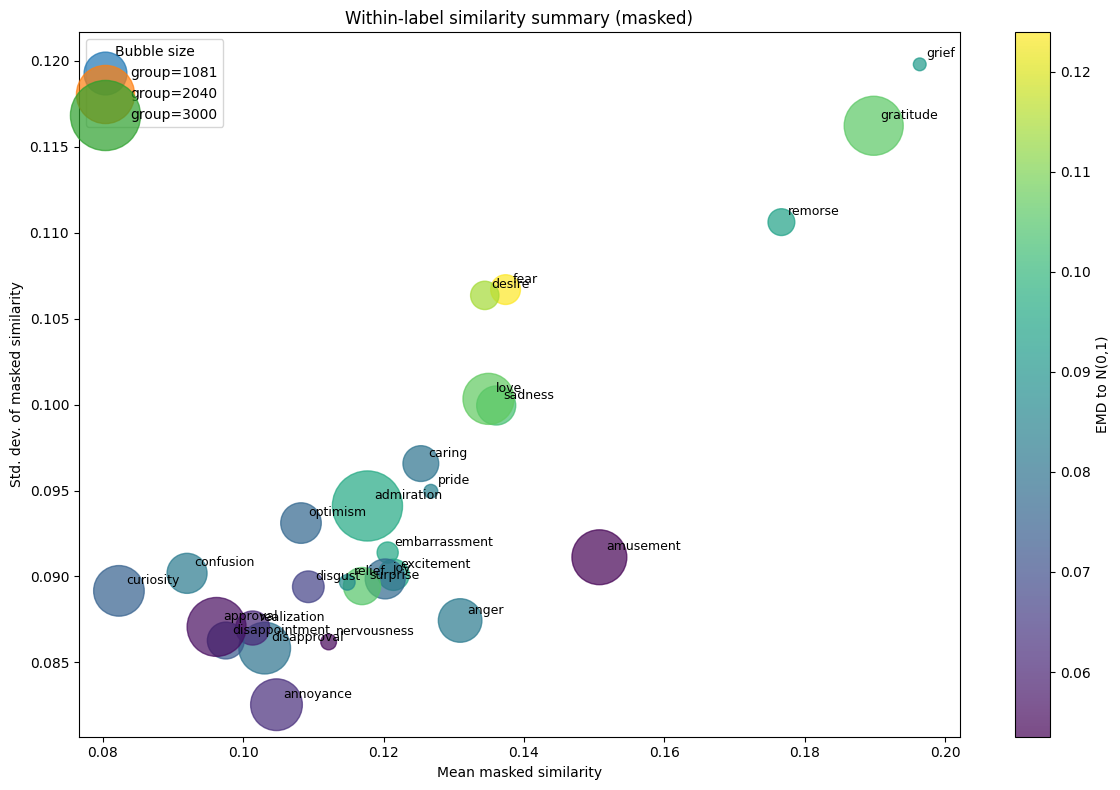

In [39]:
# Comprehensive scatter plot:
# x-axis      -> mean similarity
# y-axis      -> standard deviation of similarity
# bubble size -> group size
# bubble color -> EMD to N(0,1)

score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

# Scale bubble sizes from group size
size_scale = 2500
plot_df["bubble_size"] = (
    plot_df["group_size"] / plot_df["group_size"].max()
) * size_scale + 50

display(
    plot_df[
        ["label", mean_col, std_col, "emd_to_N01", "group_size", "n_pairs"]
    ].sort_values(mean_col, ascending=False)
)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df[mean_col],
    plot_df[std_col],
    s=plot_df["bubble_size"],
    c=plot_df["emd_to_N01"],
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row[std_col]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Within-label similarity summary ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel(f"Std. dev. of {score_prefix} similarity")

cbar = plt.colorbar(scatter)
cbar.set_label("EMD to N(0,1)")

# Bubble-size legend for group size
group_vals = np.linspace(plot_df["n_pairs"].min(), plot_df["n_pairs"].max(), 3)
legend_sizes = (group_vals / plot_df["n_pairs"].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.7, label=f"group={int(v)}")
    for s, v in zip(legend_sizes, group_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.tight_layout()
plt.show()

,label,mean_masked_similarity,std_masked_similarity,emd_to_N01,group_size,n_pairs
0,grief,0.196364,0.119782,0.091701,47,1081
1,gratitude,0.189809,0.116210,0.106052,2378,3000
2,remorse,0.176662,0.110607,0.093944,437,3000
3,amusement,0.150737,0.091119,0.053531,2046,3000
4,fear,0.137380,0.106684,0.123945,553,3000
5,sadness,0.136041,0.099943,0.102996,1003,3000
6,love,0.134945,0.100330,0.106887,1760,3000
7,desire,0.134416,0.106347,0.114573,497,3000
8,anger,0.130905,0.087442,0.081886,1265,3000
9,pride,0.126736,0.094954,0.083842,67,2211


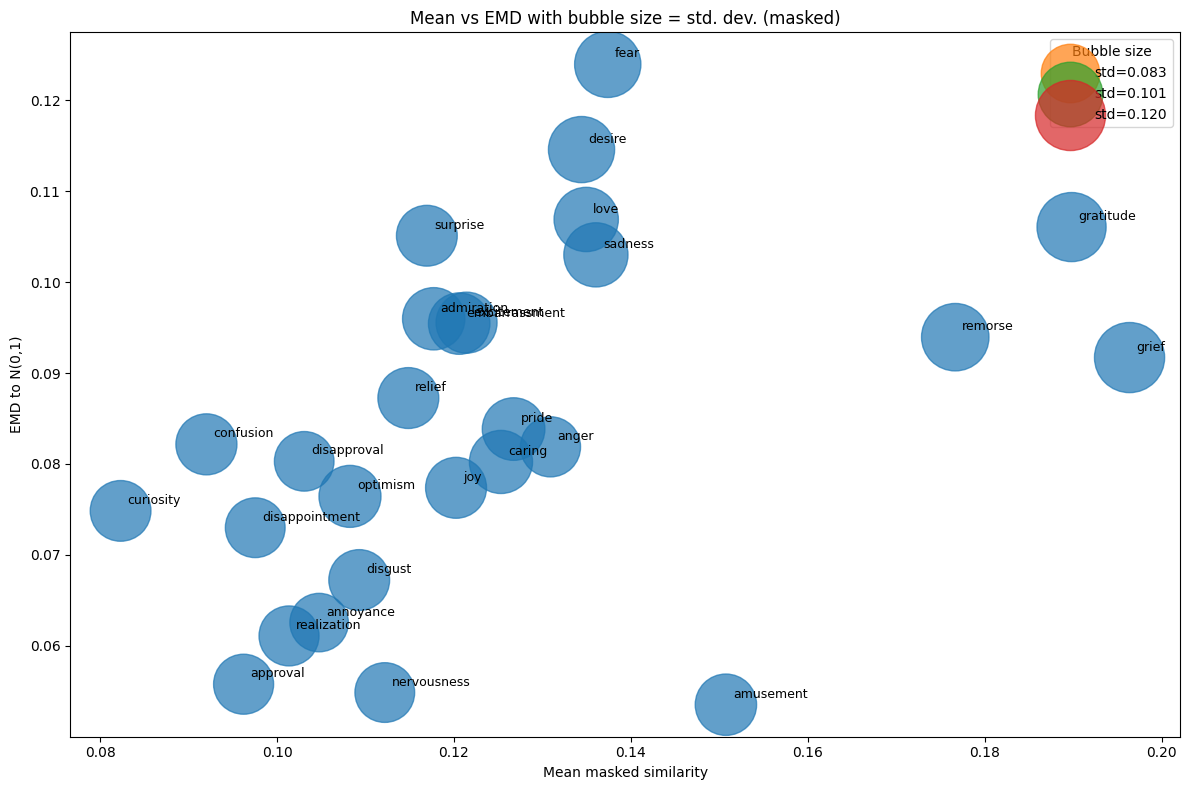

In [40]:
# Scatter plot:
# x-axis      -> mean similarity
# y-axis      -> EMD to N(0,1)
# bubble size -> standard deviation of similarity

score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

# Scale bubble sizes from standard deviation
size_scale = 2500
plot_df["bubble_size"] = (
    plot_df[std_col] / plot_df[std_col].max()
) * size_scale + 50

display(
    plot_df[
        ["label", mean_col, std_col, "emd_to_N01", "group_size", "n_pairs"]
    ].sort_values(mean_col, ascending=False)
)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df[mean_col],
    plot_df["emd_to_N01"],
    s=plot_df["bubble_size"],
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row["emd_to_N01"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Mean vs EMD with bubble size = std. dev. ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel("EMD to N(0,1)")

# Bubble-size legend for standard deviation
std_vals = np.linspace(plot_df[std_col].min(), plot_df[std_col].max(), 3)
legend_sizes = (std_vals / plot_df[std_col].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.7, label=f"std={v:.3f}")
    for s, v in zip(legend_sizes, std_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.tight_layout()
plt.show()

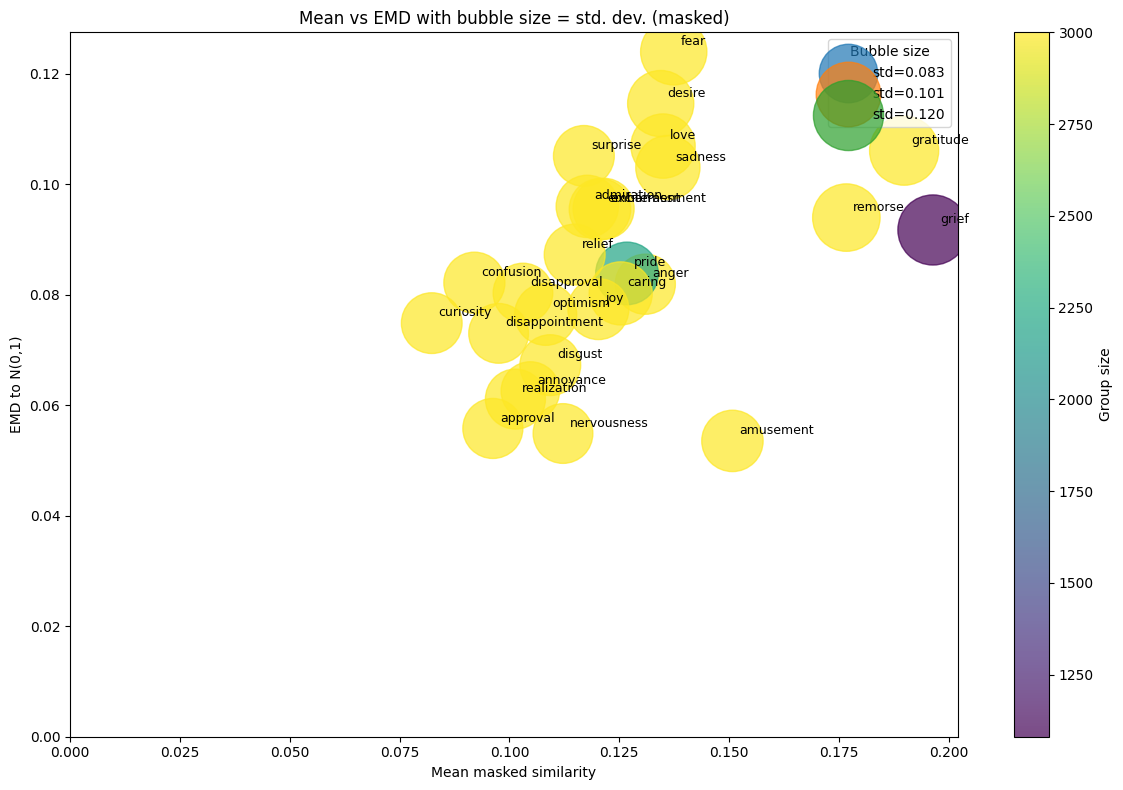

In [41]:
# Scatter plot:
# x-axis      -> mean similarity
# y-axis      -> EMD to N(0,1)
# bubble size -> standard deviation
# bubble color -> group size

score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

size_scale = 2500
plot_df["bubble_size"] = (
    plot_df[std_col] / plot_df[std_col].max()
) * size_scale + 50

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df[mean_col],
    plot_df["emd_to_N01"],
    s=plot_df["bubble_size"],
    c=plot_df["n_pairs"],
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row["emd_to_N01"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Mean vs EMD with bubble size = std. dev. ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel("EMD to N(0,1)")

cbar = plt.colorbar(scatter)
cbar.set_label("Group size")

std_vals = np.linspace(plot_df[std_col].min(), plot_df[std_col].max(), 3)
legend_sizes = (std_vals / plot_df[std_col].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.7, label=f"std={v:.3f}")
    for s, v in zip(legend_sizes, std_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

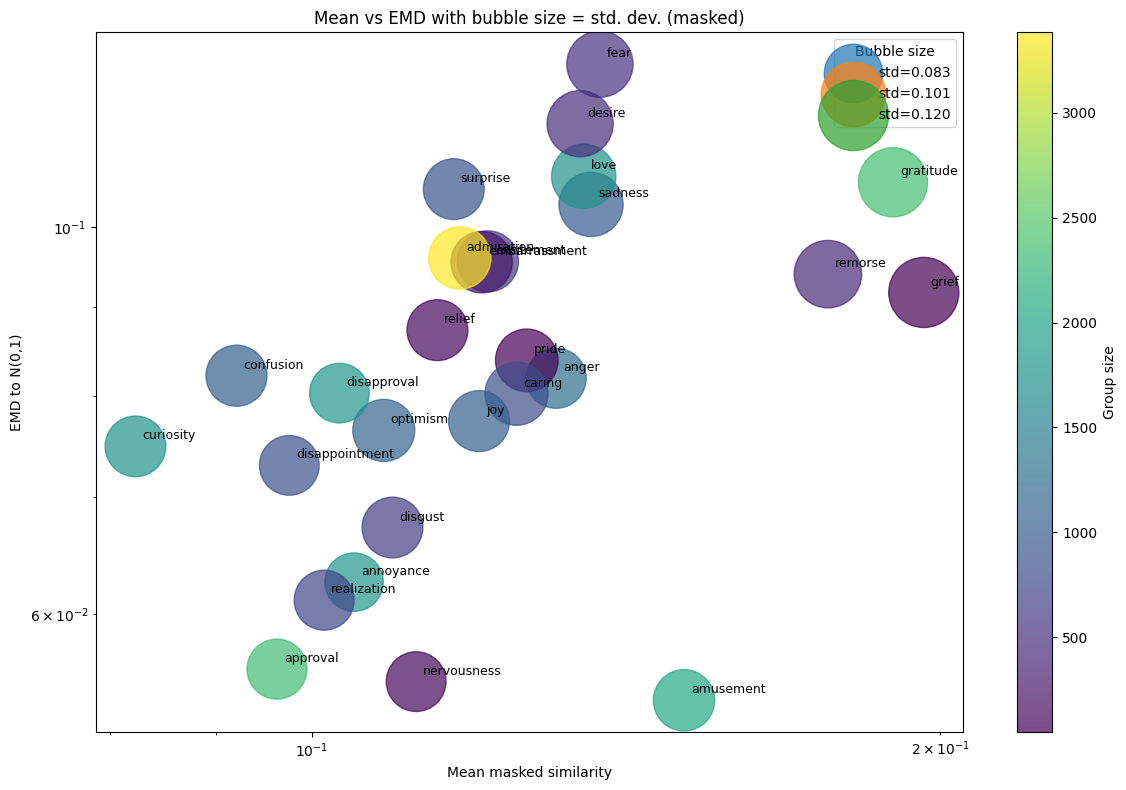

In [42]:
score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

size_scale = 2500
plot_df["bubble_size"] = (
    plot_df[std_col] / plot_df[std_col].max()
) * size_scale + 50

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df[mean_col],
    plot_df["emd_to_N01"],
    s=plot_df["bubble_size"],
    c=plot_df["group_size"],
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row["emd_to_N01"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Mean vs EMD with bubble size = std. dev. ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel("EMD to N(0,1)")

cbar = plt.colorbar(scatter)
cbar.set_label("Group size")

std_vals = np.linspace(plot_df[std_col].min(), plot_df[std_col].max(), 3)
legend_sizes = (std_vals / plot_df[std_col].max()) * size_scale + 50
handles = [
    plt.scatter([], [], s=s, alpha=0.7, label=f"std={v:.3f}")
    for s, v in zip(legend_sizes, std_vals)
]
plt.legend(handles=handles, title="Bubble size", loc="best")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

,label,mean_masked_similarity,std_masked_similarity,emd_to_N01,group_size,n_pairs
0,grief,0.196364,0.119782,0.091701,47,1081
1,gratitude,0.189809,0.116210,0.106052,2378,3000
2,remorse,0.176662,0.110607,0.093944,437,3000
3,amusement,0.150737,0.091119,0.053531,2046,3000
4,fear,0.137380,0.106684,0.123945,553,3000
5,sadness,0.136041,0.099943,0.102996,1003,3000
6,love,0.134945,0.100330,0.106887,1760,3000
7,desire,0.134416,0.106347,0.114573,497,3000
8,anger,0.130905,0.087442,0.081886,1265,3000
9,pride,0.126736,0.094954,0.083842,67,2211


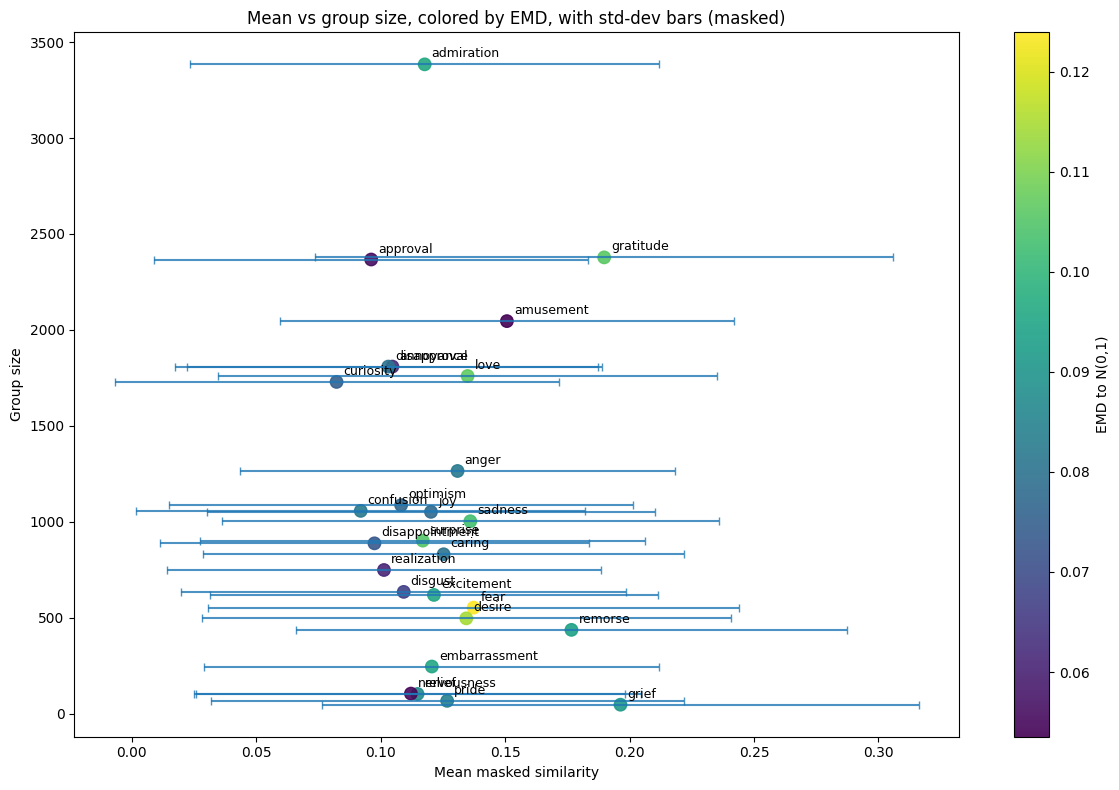

In [43]:
# Plot:
# x-axis   -> mean similarity
# y-axis   -> group size
# color    -> EMD to N(0,1)
# bars     -> standard deviation of similarity (horizontal error bars)

score_prefix = "masked"   # change to "raw" if needed

plot_df = label_similarity_summary.merge(
    emd_df[["label", "emd_to_N01"]],
    on="label",
    how="inner"
).copy()

mean_col = f"mean_{score_prefix}_similarity"
std_col = f"std_{score_prefix}_similarity"

display(
    plot_df[
        ["label", mean_col, std_col, "emd_to_N01", "group_size", "n_pairs"]
    ].sort_values(mean_col, ascending=False)
)

plt.figure(figsize=(12, 8))

# Horizontal error bars for std dev
plt.errorbar(
    plot_df[mean_col],
    plot_df["group_size"],
    xerr=plot_df[std_col],
    fmt="none",
    capsize=3,
    alpha=0.8
)

# Points colored by EMD
scatter = plt.scatter(
    plot_df[mean_col],
    plot_df["group_size"],
    c=plot_df["emd_to_N01"],
    s=80,
    alpha=0.9
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["label"],
        (row[mean_col], row["group_size"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(f"Mean vs group size, colored by EMD, with std-dev bars ({score_prefix})")
plt.xlabel(f"Mean {score_prefix} similarity")
plt.ylabel("Group size")

cbar = plt.colorbar(scatter)
cbar.set_label("EMD to N(0,1)")

# Optional: uncomment if you want log axes again
# plt.xscale("log")
# plt.yscale("log")

plt.tight_layout()
plt.show()

/tmp/ipykernel_21409/1463747395.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


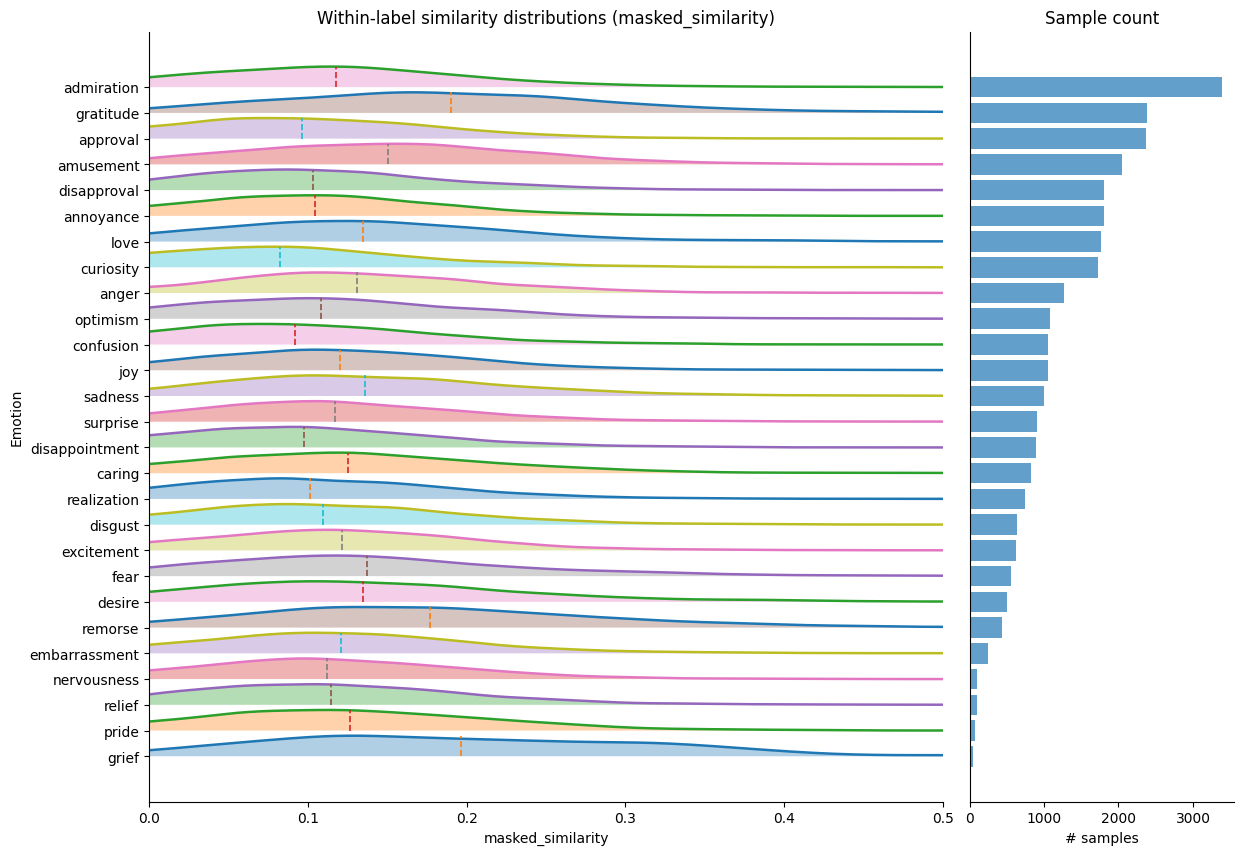

In [44]:
from scipy.stats import gaussian_kde
from matplotlib import gridspec

score_col = "masked_similarity"   # change to "raw_similarity" if needed
sample_col = "group_size"         # use "n_pairs" if you want pair counts instead

plot_df = label_similarity_summary.copy()

if score_col == "raw_similarity":
    mean_col = "mean_raw_similarity"
    std_col = "std_raw_similarity"
else:
    mean_col = "mean_masked_similarity"
    std_col = "std_masked_similarity"

# Order labels from lower to higher group size
plot_df = plot_df.sort_values("group_size", ascending=True).reset_index(drop=True)
labels_in_order = plot_df["label"].tolist()

x_min = max(0.0, label_pair_df[score_col].min() - 0.05)
x_max = min(1.0, label_pair_df[score_col].max() + 0.05)
x_grid = np.linspace(x_min, x_max, 400)

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[4.5, 1.5], wspace=0.05)

ax_ridge = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1], sharey=ax_ridge)

ridge_height = 0.8

for i, label in enumerate(labels_in_order):
    vals = label_pair_df.loc[label_pair_df["label"] == label, score_col].dropna().to_numpy()

    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals)
    density = kde(x_grid)

    if density.max() > 0:
        density = density / density.max()

    y_base = i
    y_curve = y_base + density * ridge_height

    ax_ridge.fill_between(x_grid, y_base, y_curve, alpha=0.35)
    ax_ridge.plot(x_grid, y_curve, linewidth=1.8)

    mu = plot_df.loc[plot_df["label"] == label, mean_col].iloc[0]
    ax_ridge.plot([mu, mu], [y_base, y_base + ridge_height], linewidth=1.2, linestyle="--")

ax_ridge.set_yticks(range(len(labels_in_order)))
ax_ridge.set_yticklabels(labels_in_order)
ax_ridge.set_xlabel(score_col)
ax_ridge.set_ylabel("Emotion")
ax_ridge.set_title(f"Within-label similarity distributions ({score_col})")
ax_ridge.set_xlim(x_min, 0.5)

bar_vals = plot_df[sample_col].to_numpy()
ax_bar.barh(range(len(labels_in_order)), bar_vals, height=0.8, alpha=0.7)

ax_bar.set_xlabel("# samples")
ax_bar.set_title("Sample count")
ax_bar.tick_params(axis="y", left=False, labelleft=False)

for ax in [ax_ridge, ax_bar]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## The beautiful distribution plot

/tmp/ipykernel_21409/3776100683.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


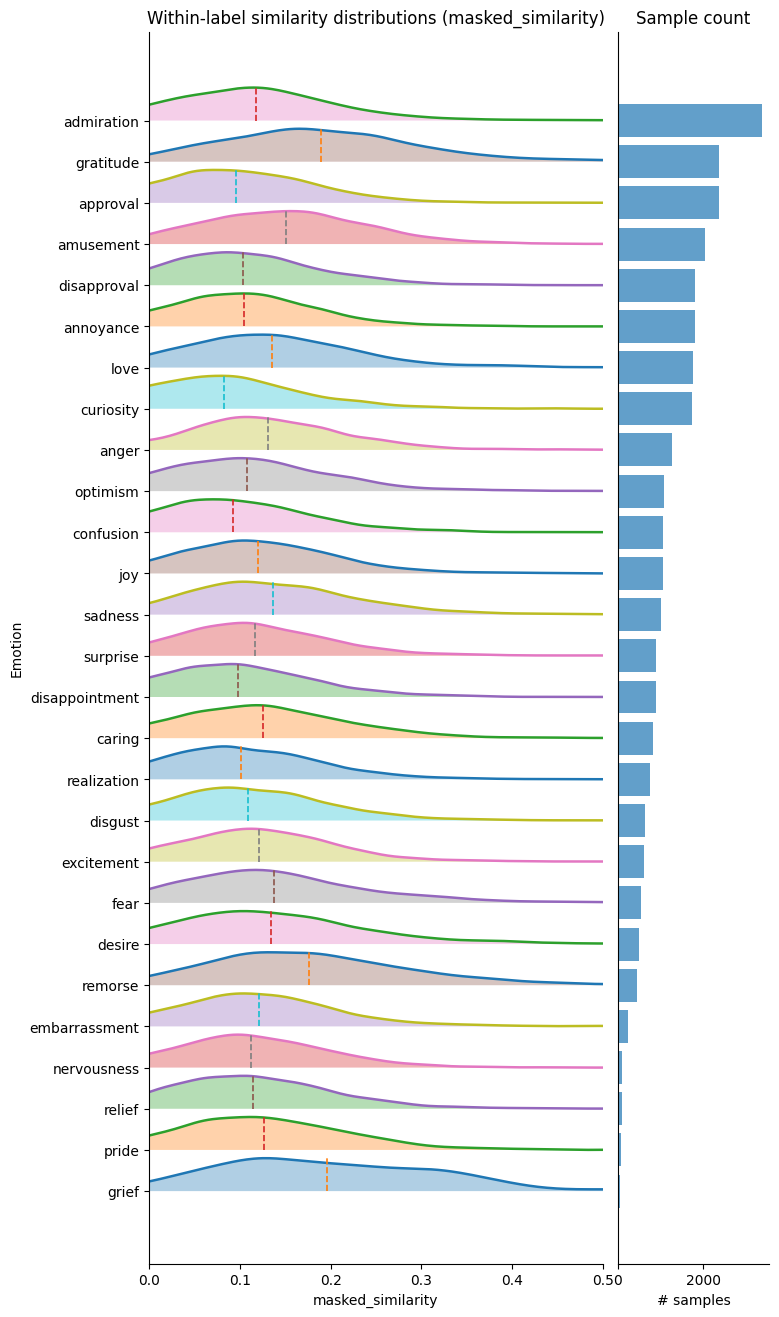

In [45]:
from scipy.stats import gaussian_kde
from matplotlib import gridspec

score_col = "masked_similarity"   # change to "raw_similarity" if needed
sample_col = "group_size"         # use "n_pairs" if you want pair counts instead

plot_df = label_similarity_summary.copy()

if score_col == "raw_similarity":
    mean_col = "mean_raw_similarity"
    std_col = "std_raw_similarity"
else:
    mean_col = "mean_masked_similarity"
    std_col = "std_masked_similarity"

# Order labels from lower to higher group size
plot_df = plot_df.sort_values("group_size", ascending=True).reset_index(drop=True)
labels_in_order = plot_df["label"].tolist()

x_min = max(0.0, label_pair_df[score_col].min() - 0.05)
x_max = min(1.0, label_pair_df[score_col].max() + 0.05)
x_grid = np.linspace(x_min, x_max, 400)

fig = plt.figure(figsize=(8, 16))
gs = gridspec.GridSpec(1, 2, width_ratios=[4.5, 1.5], wspace=0.05)

ax_ridge = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1], sharey=ax_ridge)

ridge_height = 0.8

for i, label in enumerate(labels_in_order):
    vals = label_pair_df.loc[label_pair_df["label"] == label, score_col].dropna().to_numpy()

    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals)
    density = kde(x_grid)

    if density.max() > 0:
        density = density / density.max()

    y_base = i
    y_curve = y_base + density * ridge_height

    ax_ridge.fill_between(x_grid, y_base, y_curve, alpha=0.35)
    ax_ridge.plot(x_grid, y_curve, linewidth=1.8)

    mu = plot_df.loc[plot_df["label"] == label, mean_col].iloc[0]
    ax_ridge.plot([mu, mu], [y_base, y_base + ridge_height], linewidth=1.2, linestyle="--")

ax_ridge.set_yticks(range(len(labels_in_order)))
ax_ridge.set_yticklabels(labels_in_order)
ax_ridge.set_xlabel(score_col)
ax_ridge.set_ylabel("Emotion")
ax_ridge.set_title(f"Within-label similarity distributions ({score_col})")
ax_ridge.set_xlim(x_min, 0.5)

bar_vals = plot_df[sample_col].to_numpy()
ax_bar.barh(range(len(labels_in_order)), bar_vals, height=0.8, alpha=0.7)

ax_bar.set_xlabel("# samples")
ax_bar.set_title("Sample count")
ax_bar.tick_params(axis="y", left=False, labelleft=False)

for ax in [ax_ridge, ax_bar]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [46]:
from scipy.stats import pearsonr, spearmanr

corr_rows = []

for label, group in label_pair_df.groupby("label", sort=True):
    x = group["raw_similarity"].to_numpy()
    y = group["masked_similarity"].to_numpy()

    # Need at least 2 points, and neither variable can be constant
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        corr_rows.append(
            {
                "label": label,
                "n_pairs": len(group),
                "pearson_r": np.nan,
                "pearson_p": np.nan,
                "spearman_rho": np.nan,
                "spearman_p": np.nan,
            }
        )
        continue

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    corr_rows.append(
        {
            "label": label,
            "n_pairs": len(group),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
        }
    )

corr_df = pd.DataFrame(corr_rows).sort_values("pearson_r", ascending=False).reset_index(drop=True)
display(corr_df)

,label,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p
0,desire,3000,0.837086,0.0,0.815812,0.000000e+00
1,realization,3000,0.793949,0.0,0.777020,0.000000e+00
2,curiosity,3000,0.789111,0.0,0.768682,0.000000e+00
3,confusion,3000,0.787551,0.0,0.764464,0.000000e+00
4,sadness,3000,0.784270,0.0,0.759253,0.000000e+00
5,remorse,3000,0.780717,0.0,0.767515,0.000000e+00
6,surprise,3000,0.765112,0.0,0.738120,0.000000e+00
7,admiration,3000,0.763014,0.0,0.740548,0.000000e+00
8,love,3000,0.760873,0.0,0.717202,0.000000e+00
9,amusement,3000,0.755416,0.0,0.758049,0.000000e+00


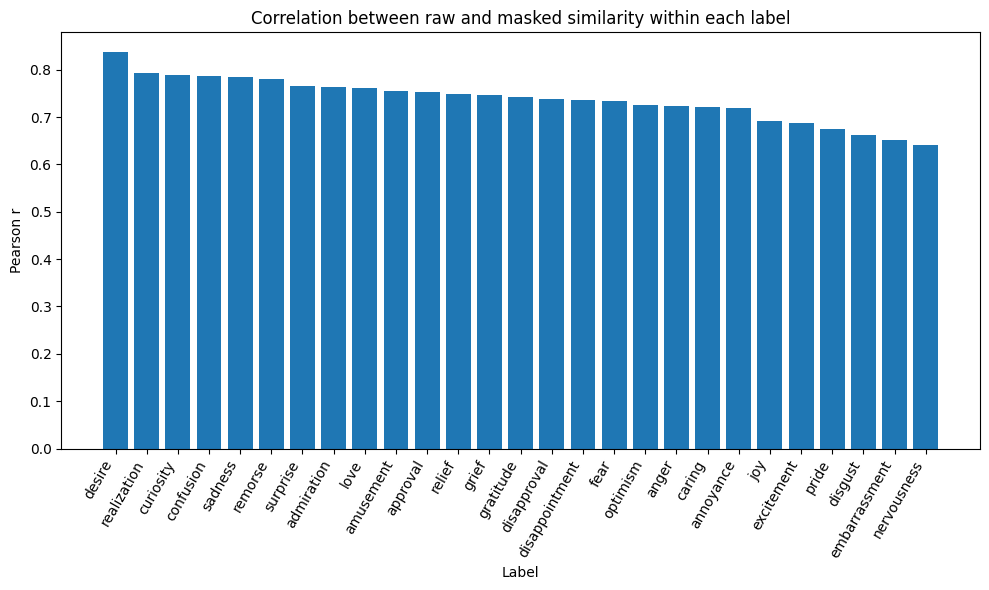

In [47]:
plt.figure(figsize=(10, 6))
plt.bar(corr_df["label"], corr_df["pearson_r"])
plt.title("Correlation between raw and masked similarity within each label")
plt.xlabel("Label")
plt.ylabel("Pearson r")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Most similar pairs

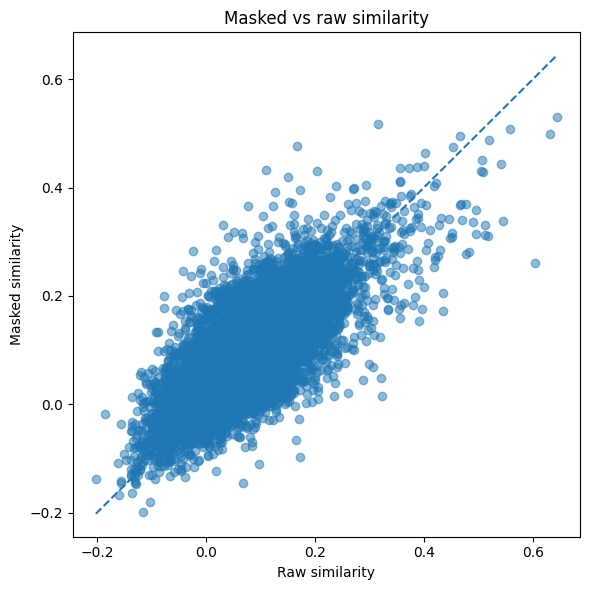

In [49]:
plt.figure(figsize=(6, 6))
plt.scatter(pair_df["raw_similarity"], pair_df["masked_similarity"], alpha=0.5)

xy_min = min(pair_df["raw_similarity"].min(), pair_df["masked_similarity"].min())
xy_max = max(pair_df["raw_similarity"].max(), pair_df["masked_similarity"].max())

plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--")
plt.title("Masked vs raw similarity")
plt.xlabel("Raw similarity")
plt.ylabel("Masked similarity")
plt.tight_layout()
plt.show()

In [50]:
example = pair_df.sample(1, random_state=RANDOM_SEED).iloc[0]

example_df = pd.DataFrame(
    {
        "field": [
            "left_text",
            "right_text",
            "left_masked",
            "right_masked",
            "raw_similarity",
            "masked_similarity",
            "similarity_delta"
        ],
        "value": [
            example["left_text"],
            example["right_text"],
            example["left_masked"],
            example["right_masked"],
            example["raw_similarity"],
            example["masked_similarity"],
            example["similarity_delta"],
        ]
    }
)

display(example_df)

,field,value
0,left_text,30 Rock is the best. I'm currently on my 1st r...
1,right_text,"Oh such a embarrassing mistake, or was it?"
2,left_masked,30 is the best I'm currently on my 1st rewatch...
3,right_masked,Oh such a or was it
4,raw_similarity,-0.017627
5,masked_similarity,0.086951
6,similarity_delta,0.104577


In [51]:
print("Most similar random pairs:")
display(
    pair_df[
        ["left_text", "right_text", "left_masked", "right_masked", "raw_similarity", "masked_similarity"]
    ]
    .sort_values("raw_similarity", ascending=False)
    .head(10)
)

print("Least similar random pairs:")
display(
    pair_df[
        ["left_text", "right_text", "left_masked", "right_masked", "raw_similarity", "masked_similarity"]
    ]
    .sort_values("raw_similarity", ascending=True)
    .head(10)
)

Most similar random pairs:


,left_text,right_text,left_masked,right_masked,raw_similarity,masked_similarity
1703,"Wow, talk about being [NAME].","Typical [NAME], i know because i am one",Wow about being NAME,Typical NAME i know because i am one,0.644081,0.529741
8413,I don't care for [NAME] but I still love this....,i feel like [NAME] doesn't fit with the rest,I don't care for NAME but I still this Like it...,i feel like NAME doesn't fit with the,0.630823,0.499044
3461,I hope your daughter gets the help she needs a...,I'm so sorry for your losses. Please see a the...,I your gets the help she needs and someday get...,I'm so sorry for your losses Please see a ther...,0.604577,0.260684
5,[NAME] [NAME],"[NAME], [NAME], [NAME], [NAME] big 4 >>>",NAME NAME,NAME NAME NAME NAME big 4,0.558625,0.508669
6314,[NAME] is a nut; he has a rubber butt!,"I never really hated [NAME], but now I love [N...",NAME is a nut he has a rubber,I never really hated NAME but now I NAME,0.544624,0.338866
8486,This way it becomes undeniably clear that it i...,[NAME] knew [NAME] were meddling tho,This way it becomes undeniably clear that it i...,NAME knew NAME were meddling tho,0.540510,0.442468
4297,I will pray for you. [NAME] bless,thank [NAME]. maybe we will finally get to hav...,I will for you NAME,thank NAME maybe we will get to have some of l...,0.519679,0.488560
7394,Isn't that why [NAME] is playing him?,[NAME]? (joke),Isn't that why NAME is playing him,NAME,0.518006,0.309807
3046,OH MY [NAME],"And [NAME], would again like to apologize for ...",OH MY NAME,And NAME would again like to for any,0.512521,0.312726
7445,Hahaha. Oh [NAME]. Way to ruin the fun lol,[NAME]? That’s your answer?,Hahaha Oh NAME Way to the lol,NAME That s your answer,0.511230,0.330217


Least similar random pairs:


,left_text,right_text,left_masked,right_masked,raw_similarity,masked_similarity
2465,"Thanks! Oddly enough, it's actually the first ...","No, he wasn't the entire problem, but his perf...",Thanks Oddly enough it's actually the first pl...,No he wasn't the entire but his performance ca...,-0.202201,-0.138018
4565,"Well for the relative dying, they can think th...","Sweet, congrats!",Well for the they can think the of is a and th...,congrats,-0.185434,-0.018235
9928,Good to know! We didn't get any when we went F...,">First of All, Nationalism ≠ Protectionsim. Ex...",to know We didn't get any when we went Friday ...,First of All Nationalism Protectionsim me yes ...,-0.160822,-0.108349
3508,"Appreciate the reply, I'll look into these. Th...",I wonder how it's still tagged questionable...,Appreciate the reply I'll look into these Than...,I wonder how it's still tagged,-0.159482,-0.167263
3283,"thanks, just sold my house to go all in",There are two kinds of people in this world. T...,thanks just sold my house to go all in,There are two kinds of people in this world Th...,-0.156877,-0.144753
9276,I'm still a little surprised at how god awful ...,I don't know how long I should wait or if its ...,I'm still a little at how that was The Bengals...,I don't know how I should or if its even a ide...,-0.156473,-0.036794
6116,The mood changes are semi controllable with me...,He was born in Scotland so as much as I’d love...,The mood changes are semi controllable with me...,He was born in Scotland so as much as I d him ...,-0.155946,-0.141686
6741,There isn't. It only exists in the heads of th...,Yayyy!!! Go little green bean go!!! Good job t...,There isn't It only exists in the heads of tho...,Yayyy Go little bean go,-0.151347,-0.091855
973,"Definitely leave him. However, you don’t owe h...",At least they have picked up some good humanis...,Definitely him However you t owe him anything ...,At least they have picked up some humanist not...,-0.146148,-0.102802
8421,"I'm not assuming anything, I've stated product...","Hey, [NAME] isn't *that* annoying",I'm not assuming anything I've stated products...,Hey NAME isn't that,-0.142243,-0.079370


# Cluster distance

In [52]:
import itertools
import torch
import torch.nn.functional as F

def sample_cross_pairs(left_indices, right_indices, max_pairs, rng):
    """
    Sample up to max_pairs pairs across two disjoint index sets.
    Returns a list of (i, j).
    """
    left_indices = np.asarray(left_indices)
    right_indices = np.asarray(right_indices)

    if len(left_indices) == 0 or len(right_indices) == 0:
        return []

    total_possible = len(left_indices) * len(right_indices)
    target = min(max_pairs, total_possible)

    # If small enough, enumerate all pairs
    if total_possible <= target:
        return [(int(i), int(j)) for i in left_indices for j in right_indices]

    # Otherwise random sample without trying to enumerate all
    pairs = set()
    while len(pairs) < target:
        i = int(rng.choice(left_indices))
        j = int(rng.choice(right_indices))
        pairs.add((i, j))

    return list(pairs)


max_cross_pairs_per_label_pair = 3000
random_seed = 42
rng = np.random.default_rng(random_seed)

inter_rows = []

labels = sorted(single_label_df["single_label"].unique())

for label_a, label_b in itertools.combinations(labels, 2):
    idx_a = single_label_df.index[single_label_df["single_label"] == label_a].to_numpy()
    idx_b = single_label_df.index[single_label_df["single_label"] == label_b].to_numpy()

    sampled_pairs = sample_cross_pairs(idx_a, idx_b, max_cross_pairs_per_label_pair, rng)

    if len(sampled_pairs) == 0:
        continue

    left_idx = torch.tensor([i for i, j in sampled_pairs], dtype=torch.long)
    right_idx = torch.tensor([j for i, j in sampled_pairs], dtype=torch.long)

    raw_sim = F.cosine_similarity(
        single_label_raw_emb[left_idx],
        single_label_raw_emb[right_idx],
        dim=1
    ).cpu().numpy()

    masked_sim = F.cosine_similarity(
        single_label_masked_emb[left_idx],
        single_label_masked_emb[right_idx],
        dim=1
    ).cpu().numpy()

    inter_rows.append(
        {
            "label_a": label_a,
            "label_b": label_b,
            "n_pairs": len(sampled_pairs),
            "group_a_size": len(idx_a),
            "group_b_size": len(idx_b),
            "mean_raw_similarity": raw_sim.mean(),
            "std_raw_similarity": raw_sim.std(ddof=0),
            "mean_masked_similarity": masked_sim.mean(),
            "std_masked_similarity": masked_sim.std(ddof=0),
        }
    )

inter_cluster_df = pd.DataFrame(inter_rows).sort_values(
    "mean_masked_similarity",
    ascending=False
).reset_index(drop=True)

display(inter_cluster_df.head(20))

,label_a,label_b,n_pairs,group_a_size,group_b_size,mean_raw_similarity,std_raw_similarity,mean_masked_similarity,std_masked_similarity
0,gratitude,remorse,3000,2378,437,0.102131,0.090506,0.135357,0.089521
1,grief,sadness,3000,47,1003,0.129136,0.097410,0.131049,0.092123
2,remorse,sadness,3000,437,1003,0.112419,0.097861,0.130108,0.099676
3,grief,remorse,3000,47,437,0.104463,0.095180,0.122335,0.096156
4,joy,love,3000,1052,1760,0.115474,0.089588,0.121877,0.089301
5,love,pride,3000,1760,67,0.108854,0.088224,0.121203,0.088799
6,amusement,remorse,3000,2046,437,0.095210,0.083092,0.120213,0.082585
7,joy,pride,3000,1052,67,0.113441,0.094198,0.118900,0.087449
8,excitement,joy,3000,619,1052,0.115907,0.094205,0.118198,0.088417
9,amusement,anger,3000,2046,1265,0.104883,0.084042,0.117838,0.080811


In [53]:
score_col = "mean_masked_similarity"   # change to "mean_raw_similarity" if needed

labels = sorted(single_label_df["single_label"].unique())
sim_matrix = pd.DataFrame(np.nan, index=labels, columns=labels)

# Fill diagonal with intra-cluster mean similarity
for _, row in label_similarity_summary.iterrows():
    label = row["label"]
    if score_col == "mean_masked_similarity":
        sim_matrix.loc[label, label] = row["mean_masked_similarity"]
    else:
        sim_matrix.loc[label, label] = row["mean_raw_similarity"]

# Fill off-diagonal with inter-cluster mean similarity
for _, row in inter_cluster_df.iterrows():
    a = row["label_a"]
    b = row["label_b"]
    sim_matrix.loc[a, b] = row[score_col]
    sim_matrix.loc[b, a] = row[score_col]

display(sim_matrix.round(3))

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise
admiration,0.118,0.106,0.098,0.095,0.086,0.089,0.082,0.085,0.099,0.089,...,0.110,0.115,0.096,0.093,0.108,0.090,0.102,0.094,0.100,0.103
amusement,0.106,0.151,0.118,0.110,0.103,0.101,0.096,0.090,0.101,0.103,...,0.114,0.115,0.109,0.100,0.113,0.110,0.111,0.120,0.113,0.117
anger,0.098,0.118,0.131,0.112,0.097,0.108,0.094,0.095,0.101,0.103,...,0.110,0.113,0.106,0.100,0.114,0.100,0.105,0.112,0.115,0.109
annoyance,0.095,0.110,0.112,0.105,0.094,0.099,0.096,0.088,0.090,0.096,...,0.101,0.100,0.105,0.094,0.100,0.095,0.098,0.104,0.105,0.102
approval,0.086,0.103,0.097,0.094,0.096,0.095,0.085,0.082,0.089,0.090,...,0.101,0.096,0.097,0.095,0.094,0.094,0.096,0.100,0.099,0.093
caring,0.089,0.101,0.108,0.099,0.095,0.125,0.084,0.079,0.104,0.091,...,0.108,0.107,0.108,0.107,0.104,0.092,0.108,0.117,0.114,0.090
confusion,0.082,0.096,0.094,0.096,0.085,0.084,0.092,0.082,0.078,0.085,...,0.090,0.091,0.088,0.085,0.087,0.089,0.087,0.098,0.085,0.094
curiosity,0.085,0.090,0.095,0.088,0.082,0.079,0.082,0.082,0.079,0.084,...,0.092,0.088,0.084,0.082,0.087,0.082,0.082,0.088,0.090,0.091
desire,0.099,0.101,0.101,0.090,0.089,0.104,0.078,0.079,0.134,0.088,...,0.109,0.110,0.102,0.107,0.106,0.086,0.096,0.096,0.107,0.095
disappointment,0.089,0.103,0.103,0.096,0.090,0.091,0.085,0.084,0.088,0.098,...,0.099,0.094,0.098,0.091,0.097,0.094,0.101,0.103,0.103,0.099


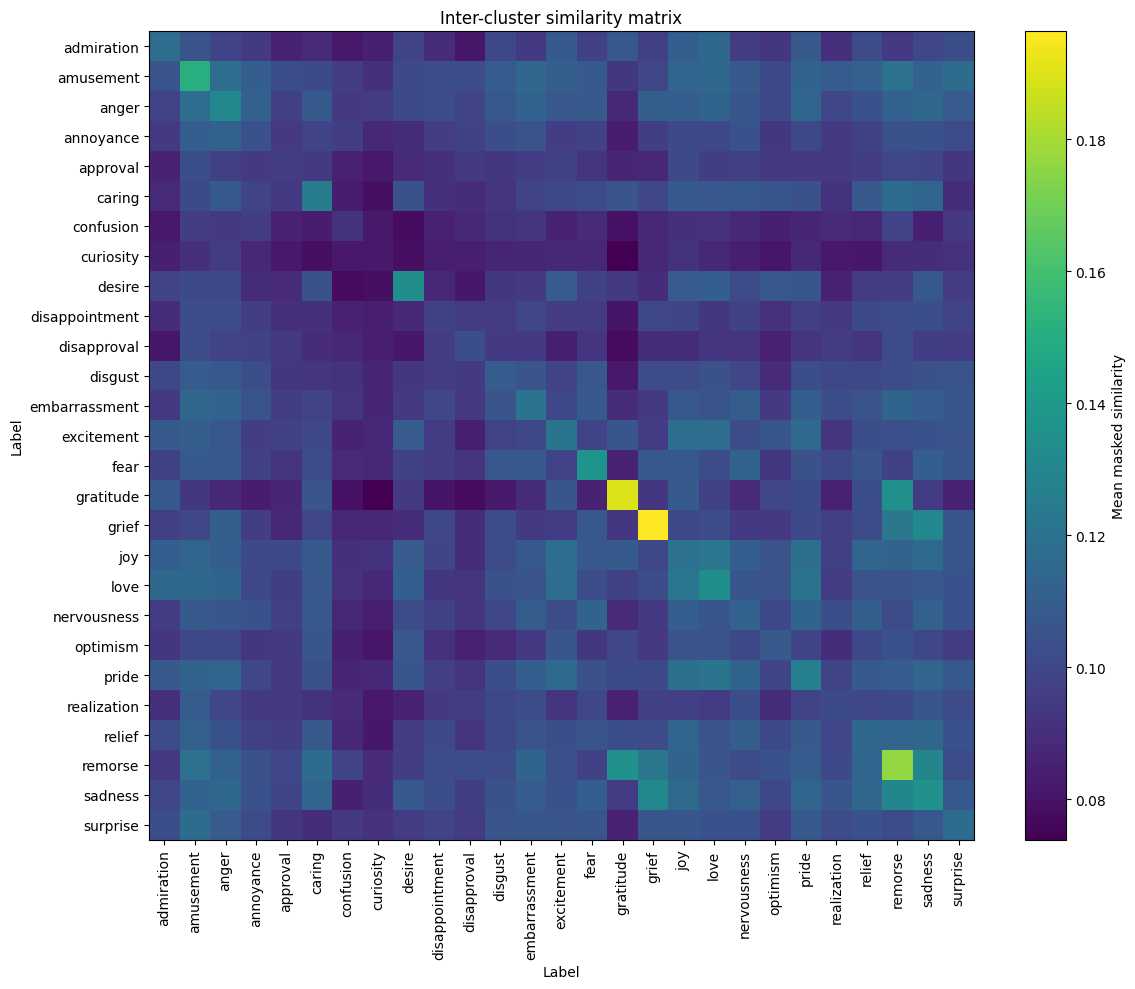

In [54]:
plt.figure(figsize=(12, 10))
im = plt.imshow(sim_matrix.values, aspect="auto")

plt.xticks(range(len(sim_matrix.columns)), sim_matrix.columns, rotation=90)
plt.yticks(range(len(sim_matrix.index)), sim_matrix.index)

plt.title("Inter-cluster similarity matrix")
plt.xlabel("Label")
plt.ylabel("Label")

cbar = plt.colorbar(im)
cbar.set_label("Mean masked similarity")

plt.tight_layout()
plt.show()

In [55]:
per_label_inter_score_rows = []

for label in labels:
    vals = []

    for other in labels:
        if other == label:
            continue
        vals.append(sim_matrix.loc[label, other])

    vals = pd.Series(vals).dropna()

    per_label_inter_score_rows.append(
        {
            "label": label,
            "mean_inter_cluster_similarity": vals.mean(),
            "min_inter_cluster_similarity": vals.min(),
            "max_inter_cluster_similarity": vals.max(),
        }
    )

per_label_inter_score_df = pd.DataFrame(per_label_inter_score_rows).sort_values(
    "mean_inter_cluster_similarity",
    ascending=True
).reset_index(drop=True)

display(per_label_inter_score_df)

,label,mean_inter_cluster_similarity,min_inter_cluster_similarity,max_inter_cluster_similarity
0,curiosity,0.085605,0.073870,0.095262
1,confusion,0.088141,0.077543,0.098464
2,disapproval,0.091689,0.077695,0.102906
3,gratitude,0.093491,0.073870,0.135357
4,approval,0.093782,0.082460,0.103403
5,disappointment,0.094952,0.080577,0.103091
6,realization,0.096105,0.082058,0.109578
7,desire,0.096366,0.077543,0.110412
8,optimism,0.096858,0.081510,0.107157
9,admiration,0.097263,0.081936,0.115029


In [56]:
compare_rows = []

intra_lookup = label_similarity_summary.set_index("label")

for _, row in per_label_inter_score_df.iterrows():
    label = row["label"]

    compare_rows.append(
        {
            "label": label,
            "mean_intra_cluster_similarity": intra_lookup.loc[label, "mean_masked_similarity"],
            "mean_inter_cluster_similarity": row["mean_inter_cluster_similarity"],
            "separation_gap": (
                intra_lookup.loc[label, "mean_masked_similarity"]
                - row["mean_inter_cluster_similarity"]
            ),
        }
    )

cluster_separation_df = pd.DataFrame(compare_rows).sort_values(
    "separation_gap",
    ascending=False
).reset_index(drop=True)

display(cluster_separation_df)

,label,mean_intra_cluster_similarity,mean_inter_cluster_similarity,separation_gap
0,grief,0.196364,0.099701,0.096662
1,gratitude,0.189809,0.093491,0.096318
2,remorse,0.176662,0.107431,0.069231
3,amusement,0.150737,0.107301,0.043435
4,desire,0.134416,0.096366,0.038050
5,fear,0.137380,0.100718,0.036662
6,love,0.134945,0.104959,0.029986
7,sadness,0.136041,0.107294,0.028747
8,caring,0.125310,0.099739,0.025571
9,anger,0.130905,0.105561,0.025344


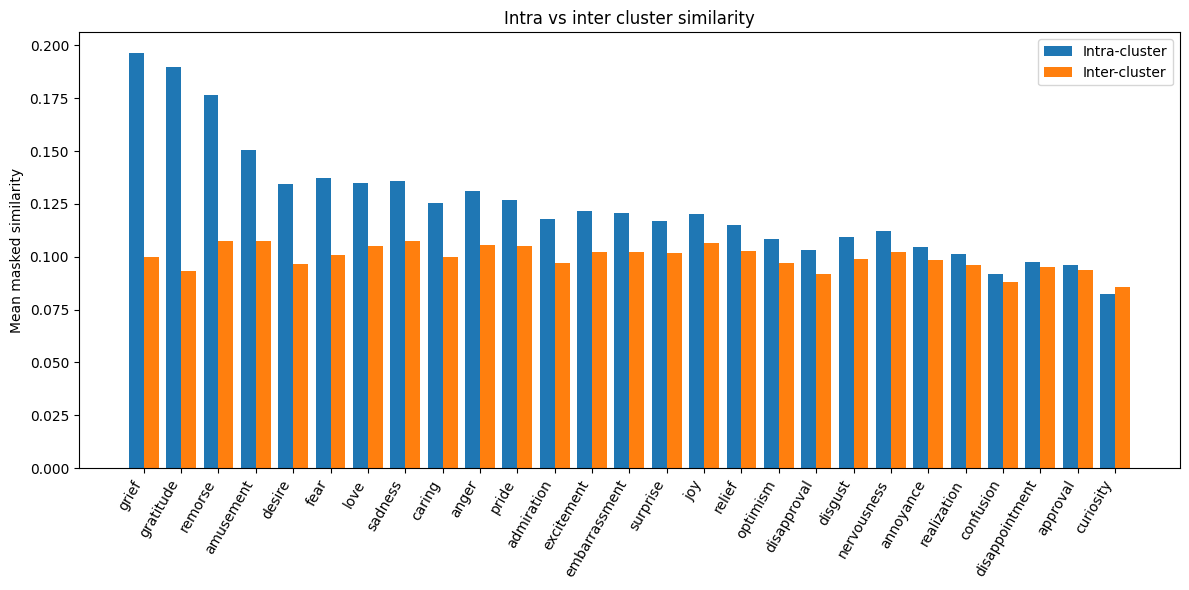

In [57]:
x = np.arange(len(cluster_separation_df))
width = 0.4

plt.figure(figsize=(12, 6))
plt.bar(
    x - width / 2,
    cluster_separation_df["mean_intra_cluster_similarity"],
    width=width,
    label="Intra-cluster"
)
plt.bar(
    x + width / 2,
    cluster_separation_df["mean_inter_cluster_similarity"],
    width=width,
    label="Inter-cluster"
)

plt.xticks(x, cluster_separation_df["label"], rotation=60, ha="right")
plt.ylabel("Mean masked similarity")
plt.title("Intra vs inter cluster similarity")
plt.legend()
plt.tight_layout()
plt.show()